# Play-style analysis of `log_power` - official Hearthstone `Power.log` format

**Data.** [`log_power/`](../log_power/) re-simulates the 9-deck matchup matrix and writes every game as a real **`Power.log`** - the packet stream the Hearthstone client itself produces (`CREATE_GAME`, `FULL_ENTITY`, `SHOW_ENTITY`, `TAG_CHANGE`, `BLOCK_START/END`), rendered from SabberStone's own `PowerHistory` and round-trip-verified against HearthSim's `hslog` parser. 5 AI play-styles (**aggro - control - fatigue - midrange - ramp**) x **9 decks** x ~900 games = **40,500 games**, ~16 GB of text.

Two properties of the format shape everything below:

1. **The viewpoint is P1's client.** The log holds only what one client saw: P1's own deck is a stack of anonymous entities until drawn, and P2's hand stays hidden. Information the simulator had is genuinely gone - that is the point of using this format.
2. **There are no decision records.** A real log records the action that was *taken*, never the set of options it was chosen *from*. The choice-relative (`ch_*`) block of the `log_v2` study cannot be rebuilt here, so this is a **simple-statistics** study by necessity.

**Labels never touch the features.** The `.log` files never name the agent; `style` / `deck` come from each cell's `summary.csv` and are joined on the file name.

> **Models & metric.** Unsupervised = **KMeans with k = 5**. Supervised = **Linear Discriminant Analysis**. Everything is scored with the **adjusted Rand index (ARI)**, so clustering and classification sit on one scale where **1.000 = perfect**. Every plot draws the **0.20 chance line** used throughout this study - random guessing among 5 equiprobable styles - so the numbers here are directly comparable with the `log_v2` notebooks. (ARI's own null expectation is 0, so a score between 0 and 0.20 is still above ARI-chance; 0.20 is the shared *reference* bar, not the floor.) PCA / t-SNE / LDA projections are for plotting only. Per-style breakdowns are reported as **recall**, because ARI scores a whole partition and has no per-class decomposition.

> **Protocols.** SS 5-6 pool all decks. SS 7 is **within-deck** (fit and score inside one deck, so the deck cannot be a confound). SS 8-9 are the cross-deck tests: **LODO** (leave-one-deck-out, 9 folds) and **LOAO** (leave-one-archetype-out, 4 folds - a whole deck family is held out so no sibling deck leaks into training). SS 10 asks how much of the cross-deck gap is just the deck's own bias.

## 1 - Setup & load

Load the precomputed per-game statistics from [`out/features.csv`](out/features.csv). Build it first if it is missing:

```
py -3 log_power_analysis/powerlog_features.py
```

`FEATURES` is every `f_*` column; the label columns (`style`, `deck`, `deck_family`, `won`, ...) are kept out of it.

In [1]:
import os, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
warnings.filterwarnings("ignore")

def _repo_root():
    """Nearest ancestor holding both log_power/ and log_power_analysis/."""
    d = os.path.abspath(os.getcwd())
    while True:
        if os.path.isdir(os.path.join(d, "log_power")) and os.path.isdir(os.path.join(d, "log_power_analysis")):
            return d
        p = os.path.dirname(d)
        if p == d:
            raise FileNotFoundError("repo root (with log_power/ + log_power_analysis/) not found from " + os.getcwd())
        d = p
ROOT = _repo_root()
FEATURES_CSV = os.path.join(ROOT, "log_power_analysis", "out", "features.csv")
if not os.path.isfile(FEATURES_CSV):
    raise FileNotFoundError(
        f"{FEATURES_CSV} not found.\nBuild it first (~2-5 min over the 16 GB of logs):\n"
        f"    py -3 log_power_analysis/powerlog_features.py\n"
        f"or for a quick pass:  py -3 log_power_analysis/powerlog_features.py --limit 100")

%matplotlib inline
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.width", 200)

STYLE_ORDER  = ["aggro", "control", "fatigue", "midrange", "ramp"]
STYLE_COLORS = dict(zip(STYLE_ORDER, ["#d62728", "#1f77b4", "#9467bd", "#2ca02c", "#ff7f0e"]))
CHANCE = 0.20  # reference line shared with the log_v2 notebooks (5 equiprobable styles)

df = pd.read_csv(FEATURES_CSV)
df = df.dropna(subset=["style", "deck"]).copy()
df["style"] = pd.Categorical(df["style"], categories=STYLE_ORDER, ordered=True)

FEATURES = [c for c in df.columns if c.startswith("f_")]
DECKS    = sorted(df["deck"].unique())
FAMILIES = sorted(df["deck_family"].dropna().unique())

def styles_of(frame):
    """Style labels as a plain numpy object array (sklearn cannot index a pandas
    extension array inside joblib workers)."""
    return np.asarray(frame["style"].astype(str), dtype=object)

def kind_of(col):
    if col in ("f_n_turns", "f_max_card_cost", "f_first_minion_turn", "f_deck_left_end",
               "f_board_size_max"):
        return "disc"
    if col.endswith("_frac") or col.endswith("_ratio") or col.endswith("_share") or col.endswith("_efficiency"):
        return "clip01"
    return "kde"

print(f"models: unsupervised = KMeans(k=5)   supervised = LDA   metric = ARI (chance line = 0.20)")
print(f"features.csv: {df.shape}  |  {len(FEATURES)} simple statistics")
print(f"decks ({len(DECKS)}): {DECKS}")
print(f"families ({len(FAMILIES)}): {FAMILIES}")
print("\ngames per style:")
print(df["style"].value_counts().reindex(STYLE_ORDER).to_string())
print("\ngames per deck x style:")
display(pd.crosstab(df["deck"], df["style"]))
print(f"overall P1 win rate: {df['won'].mean():.1%}")
df[["game_file", "style", "deck", "deck_family", "won", "f_n_turns"]].head(3)

models: unsupervised = KMeans(k=5)   supervised = LDA   metric = ARI (chance line = 0.20)
features.csv: (40497, 45)  |  35 simple statistics
decks (9): ['AggroPirateWarrior', 'MidrangeBuffPaladin', 'MidrangeJadeShaman', 'MidrangeSecretHunter', 'MiraclePirateRogue', 'MurlocDruid', 'RenoKazakusDragonPriest', 'RenoKazakusMage', 'ZooDiscardWarlock']
families (4): ['aggro', 'combo_tempo', 'highlander_control', 'midrange']

games per style:
style
aggro       8100
control     8098
fatigue     8100
midrange    8100
ramp        8099

games per deck x style:


style,aggro,control,fatigue,midrange,ramp
deck,,,,,
AggroPirateWarrior,900,900,900,900,900
MidrangeBuffPaladin,900,900,900,900,900
MidrangeJadeShaman,900,900,900,900,899
MidrangeSecretHunter,900,900,900,900,900
MiraclePirateRogue,900,900,900,900,900
MurlocDruid,900,900,900,900,900
RenoKazakusDragonPriest,900,900,900,900,900
RenoKazakusMage,900,898,900,900,900
ZooDiscardWarlock,900,900,900,900,900


overall P1 win rate: 49.9%


,game_file,style,deck,deck_family,won,f_n_turns
0,game_001_aggro-AggroPirateWarrior_vs_aggro-Agg...,aggro,AggroPirateWarrior,aggro,0,5
1,game_001_aggro-AggroPirateWarrior_vs_aggro-Mid...,aggro,AggroPirateWarrior,aggro,0,7
2,game_001_aggro-AggroPirateWarrior_vs_aggro-Mid...,aggro,AggroPirateWarrior,aggro,1,5


### 1b - Feature glossary

**35 simple statistics**, all for **P1 (the folder's play-style)**, one value per game. Every one is a plain count, rate, mean, max or standard deviation over the game - no sequence models, no embeddings, nothing learned. They are read out of the `Power.log` packet stream by [`powerlog_features.py`](powerlog_features.py):

* `BLOCK_START BlockType=PLAY` / `ATTACK` on a P1 entity -> what P1 did;
* the entity registry built from `FULL_ENTITY` / `SHOW_ENTITY` -> the card's `COST`, `CARDTYPE`, `ATK`, `HEALTH`;
* `TAG_CHANGE` on `DAMAGE` / `ARMOR` / `ZONE` / `RESOURCES` -> life totals, deaths, draws, mana.

**Nothing here is a `log_v2` choice-relative (`ch_*`) feature.** A real client log records the action that was *taken*, never the set of legal options it was chosen *from*, so the denominator those metrics need does not exist in this format. That is the price of the realistic format, and it is why this notebook is a **raw-statistics** study.

| feature (column) | play-style aspect | definition |
|---|---|---|
| `f_n_turns` | game length | number of turns P1 actually took |
| `f_actions_per_turn` | activity | (card plays + attacks + hero powers) / P1 turns |
| `f_cards_per_turn` | tempo | cards played from hand / P1 turns |
| `f_cards_drawn_per_turn` | card advantage | cards drawn after the mulligan / P1 turns |
| `f_avg_card_cost` | curve centre | mean mana cost of the cards P1 played |
| `f_max_card_cost` | reach / top end | highest mana cost P1 played |
| `f_std_card_cost` | curve spread | sd of the costs P1 played |
| `f_minion_frac` | card-type mix | minions / all cards played |
| `f_spell_frac` | card-type mix | spells / all cards played |
| `f_weapon_frac` | card-type mix | weapons / all cards played |
| `f_avg_minion_atk` | minion profile | mean ATK of the minions P1 played |
| `f_avg_minion_health` | minion profile | mean HEALTH of the minions P1 played |
| `f_first_minion_turn` | board development | P1 turn on which the first minion hit the board |
| `f_attacks_per_turn` | aggression intensity | attack declarations / P1 turns |
| `f_face_attack_ratio` | aggression direction | attacks aimed at the enemy hero / all attacks |
| `f_hero_power_per_turn` | hero-power tempo | hero-power activations / P1 turns |
| `f_hero_power_frac` | hero-power habit | hero powers / all P1 actions |
| `f_targeted_play_frac` | interaction | plays that named a target / all plays |
| `f_target_face_frac` | reach vs removal | targeted plays aimed at the enemy hero / targeted plays |
| `f_face_dmg_per_turn` | life pressure | damage landed on the enemy hero / P1 turns |
| `f_minion_dmg_per_turn` | board pressure | damage P1 dealt to enemy minions / P1 turns |
| `f_face_dmg_share` | aggro vs value | face damage / all damage P1 dealt |
| `f_dmg_taken_per_turn` | damage absorbed | damage landed on P1's hero / P1 turns |
| `f_heal_per_turn` | sustain | healing on P1's hero / P1 turns |
| `f_armor_gain_per_turn` | sustain | armour gained by P1's hero / P1 turns |
| `f_board_size_mean` | board presence | mean P1 minions in play at the end of P1's turns |
| `f_board_size_max` | board presence | largest P1 board seen |
| `f_opp_minions_killed_per_turn` | removal / trading | enemy minions sent to the graveyard / P1 turns |
| `f_own_minions_lost_per_turn` | attrition | own minions lost / P1 turns |
| `f_trade_ratio` | trade quality | enemy minions killed / (killed + own lost) |
| `f_mana_spent_per_turn` | tempo | mana actually spent / P1 turns |
| `f_mana_floated_per_turn` | greed / inefficiency | unspent mana left at end of turn / P1 turns |
| `f_mana_efficiency` | curve fit | mana spent / mana available over the game |
| `f_hand_size_mean` | hoarding | mean P1 hand size at the end of P1's turns |
| `f_deck_left_end` | fatigue tell | cards still in P1's deck when the game ended |

## 2 - Per-style distribution grids

One grid **per style**, pooled over all 9 decks. Dashed line = that style's mean. Watch the shapes shift from **aggro** (short games, face damage, cheap curve) toward the value styles (long games, expensive curve, healing, empty decks).

In [2]:
def _plot_metric(ax, s, kind, color):
    s = s.dropna()
    if not len(s):
        return
    if kind == "disc":
        sns.histplot(s.round().astype(int), discrete=True, color=color, ax=ax, stat="density")
    elif kind == "clip01":
        sns.histplot(s.clip(0, 1), kde=(s.nunique() > 1), color=color, ax=ax, stat="density")
    else:
        sns.histplot(s, kde=(s.nunique() > 1), color=color, ax=ax, stat="density")
    ax.axvline(s.mean(), color="k", ls="--", lw=1)

def _grid_shape(n, ncol=5):
    return int(np.ceil(n / ncol)), ncol

def show_style(style):
    gp = df[df["style"] == style]
    display(Markdown(f"### `{style}`  -  {len(gp)} games  -  win {gp['won'].mean():.1%}  -  "
                     f"avg {gp['f_n_turns'].mean():.1f} turns"))
    nrow, ncol = _grid_shape(len(FEATURES))
    fig, axes = plt.subplots(nrow, ncol, figsize=(17, 2.6 * nrow)); axes = np.atleast_1d(axes).ravel()
    for ax, col in zip(axes, FEATURES):
        _plot_metric(ax, gp[col], kind_of(col), STYLE_COLORS[style])
        ax.set_title(col, fontsize=8); ax.set_xlabel(""); ax.set_ylabel("")
    for ax in axes[len(FEATURES):]:
        ax.axis("off")
    fig.suptitle(f"{style} - per-game Power.log statistics (all {len(DECKS)} decks pooled)",
                 fontsize=13, color=STYLE_COLORS[style])
    fig.tight_layout(rect=[0, 0, 1, 0.98]); plt.show()

### `aggro`  -  8100 games  -  win 28.9%  -  avg 7.2 turns

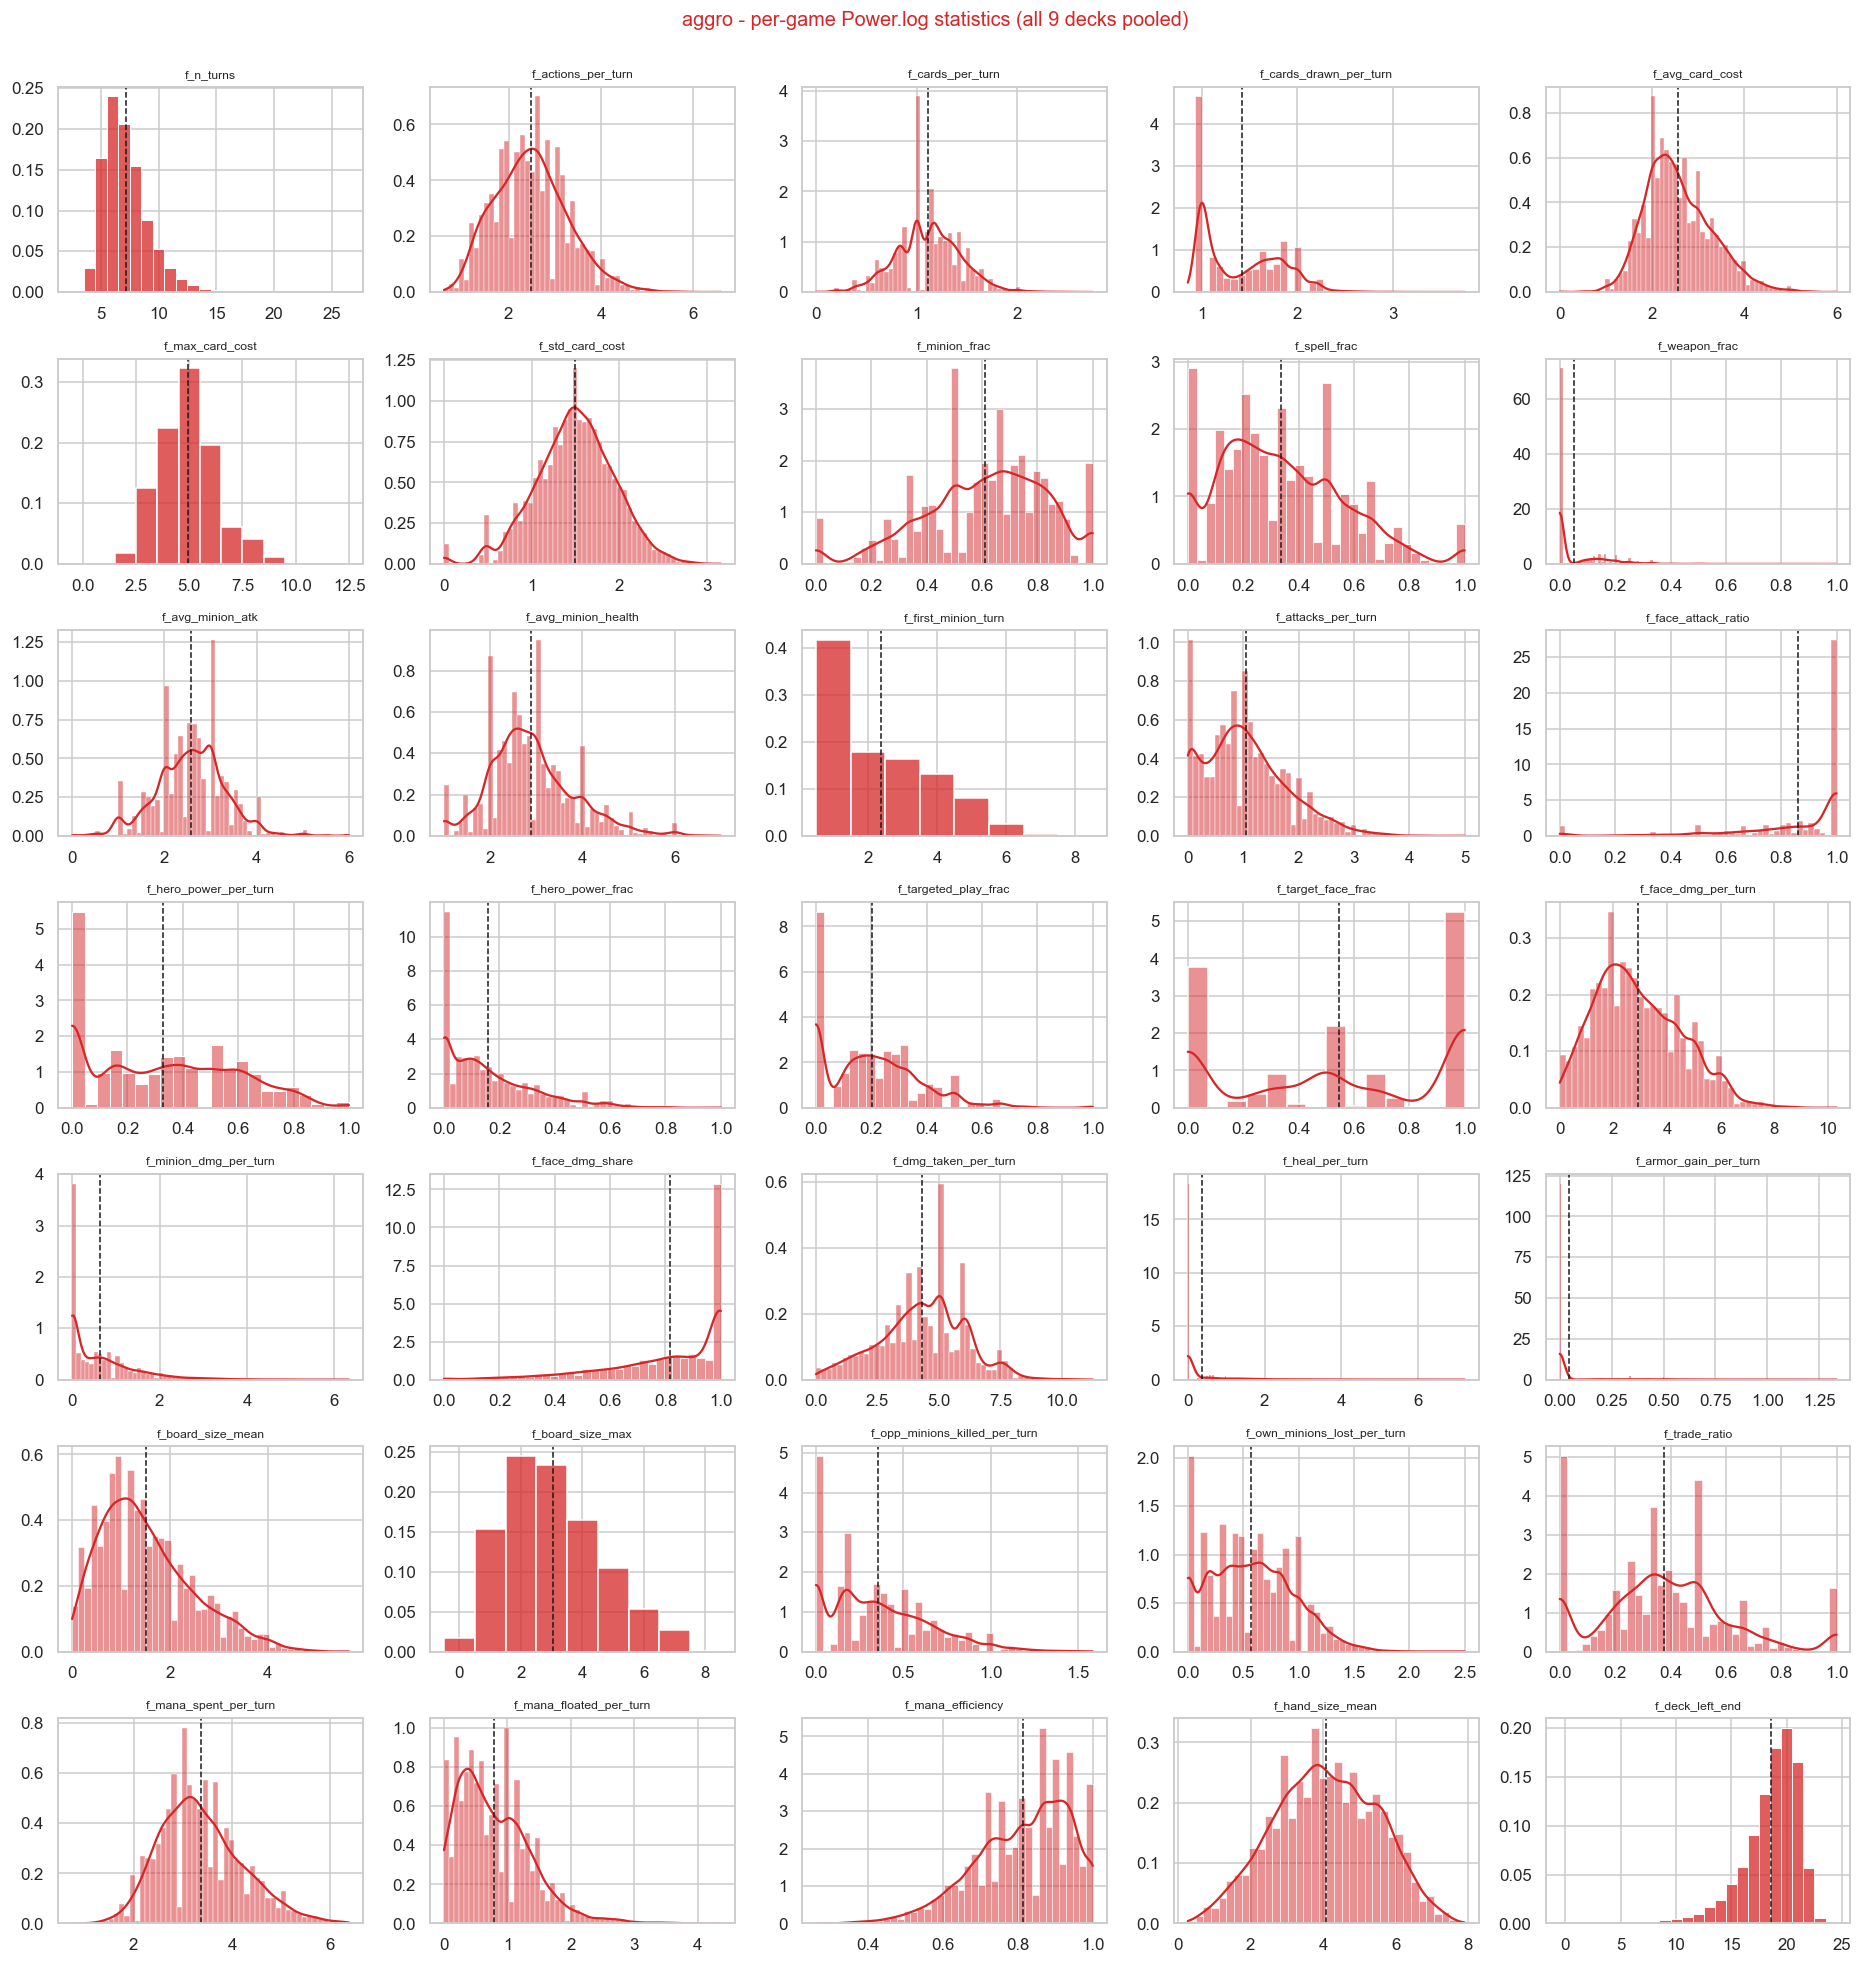

In [3]:
show_style("aggro")

### `control`  -  8098 games  -  win 54.3%  -  avg 9.0 turns

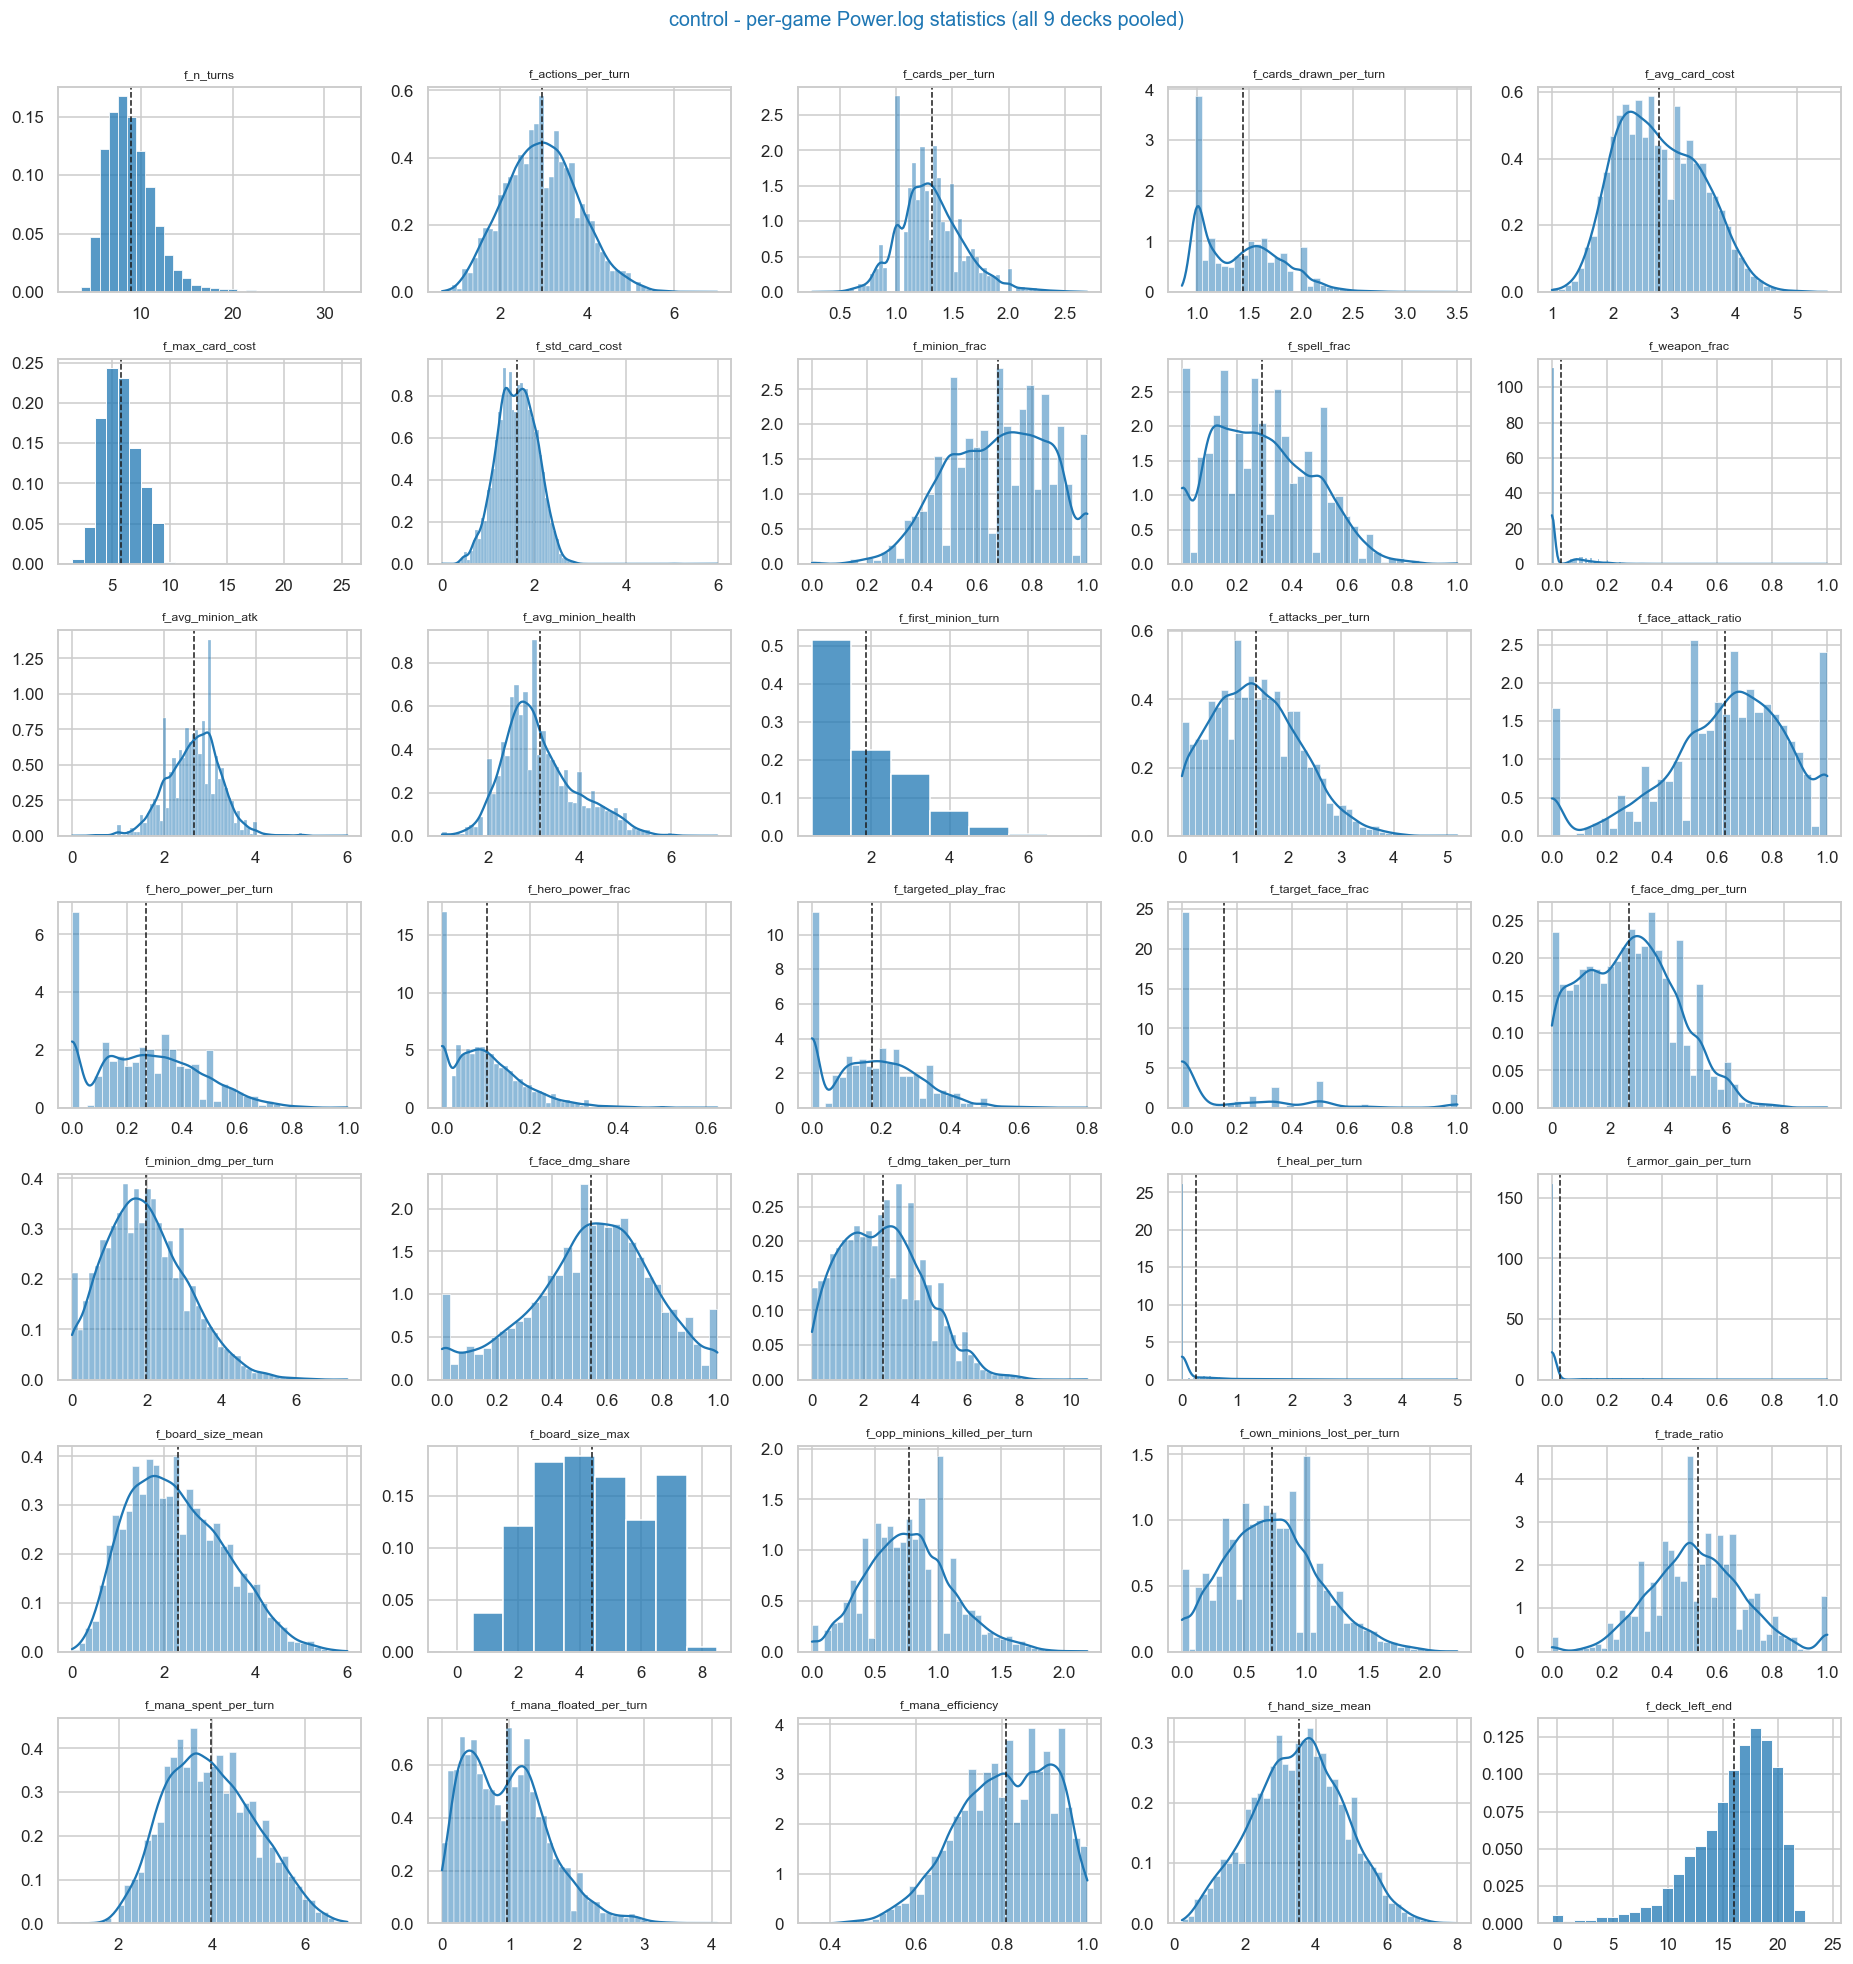

In [4]:
show_style("control")

### `fatigue`  -  8100 games  -  win 42.1%  -  avg 8.5 turns

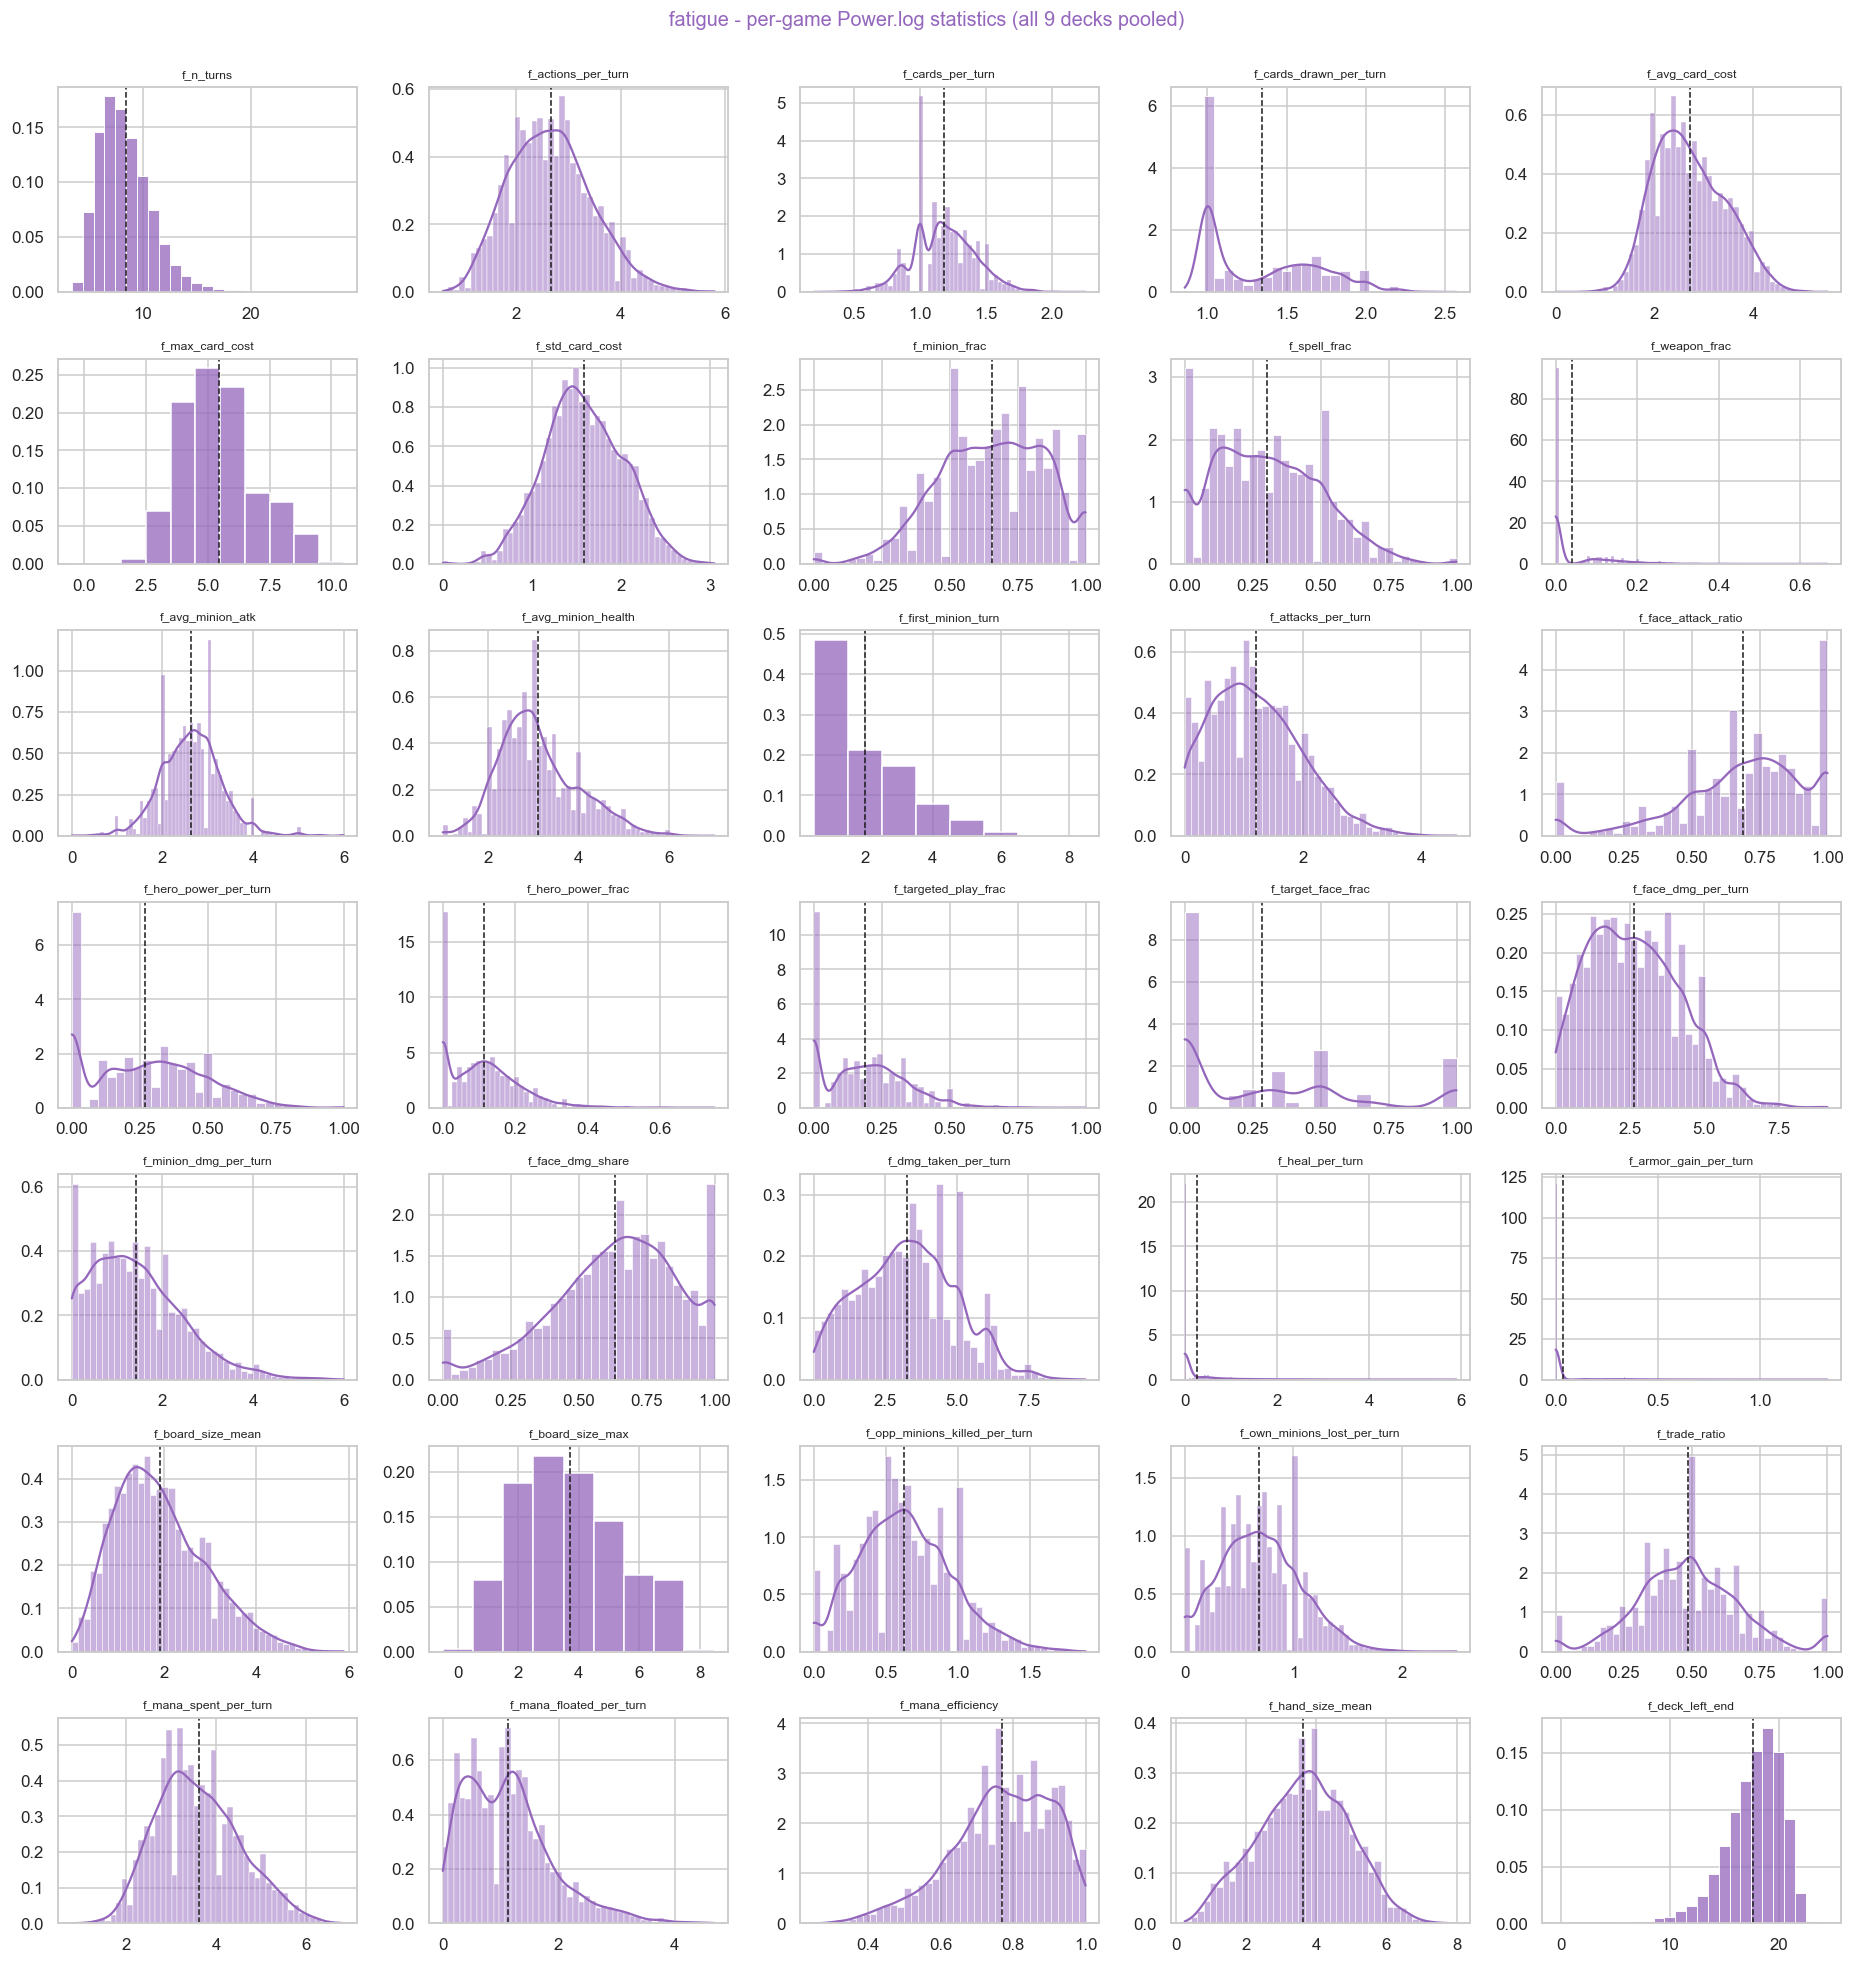

In [5]:
show_style("fatigue")

### `midrange`  -  8100 games  -  win 62.0%  -  avg 8.7 turns

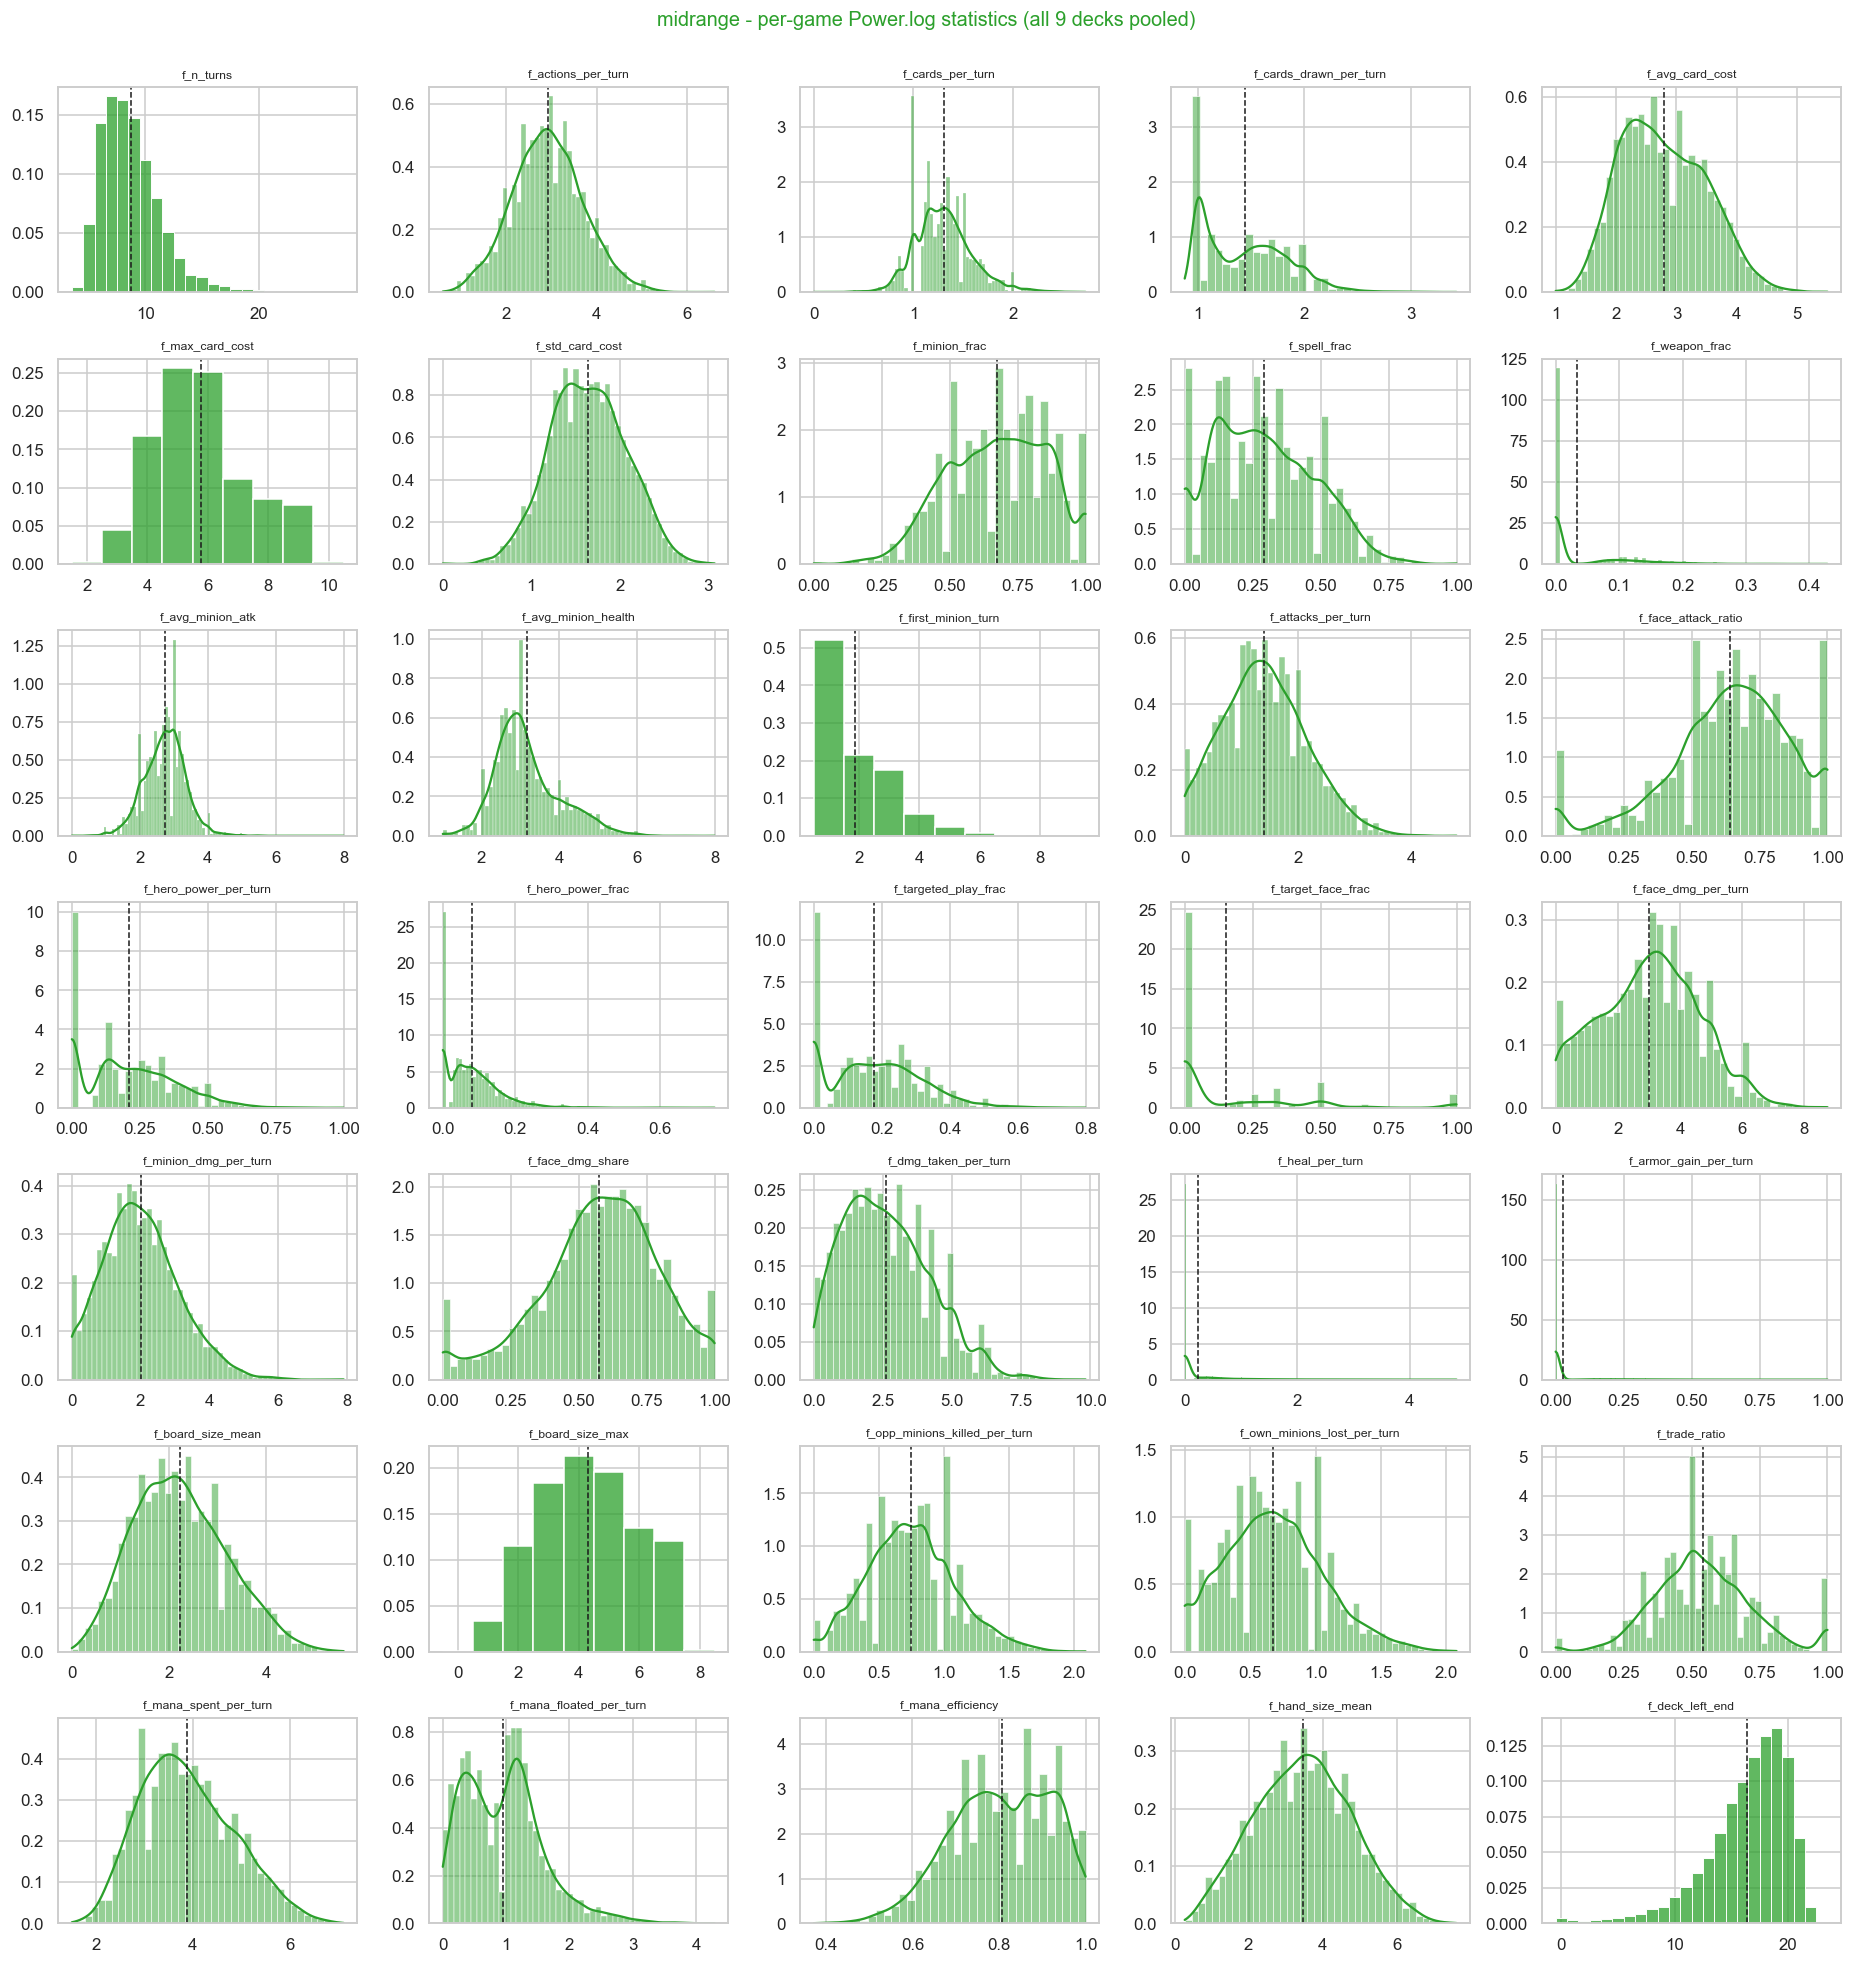

In [6]:
show_style("midrange")

### `ramp`  -  8099 games  -  win 62.4%  -  avg 9.2 turns

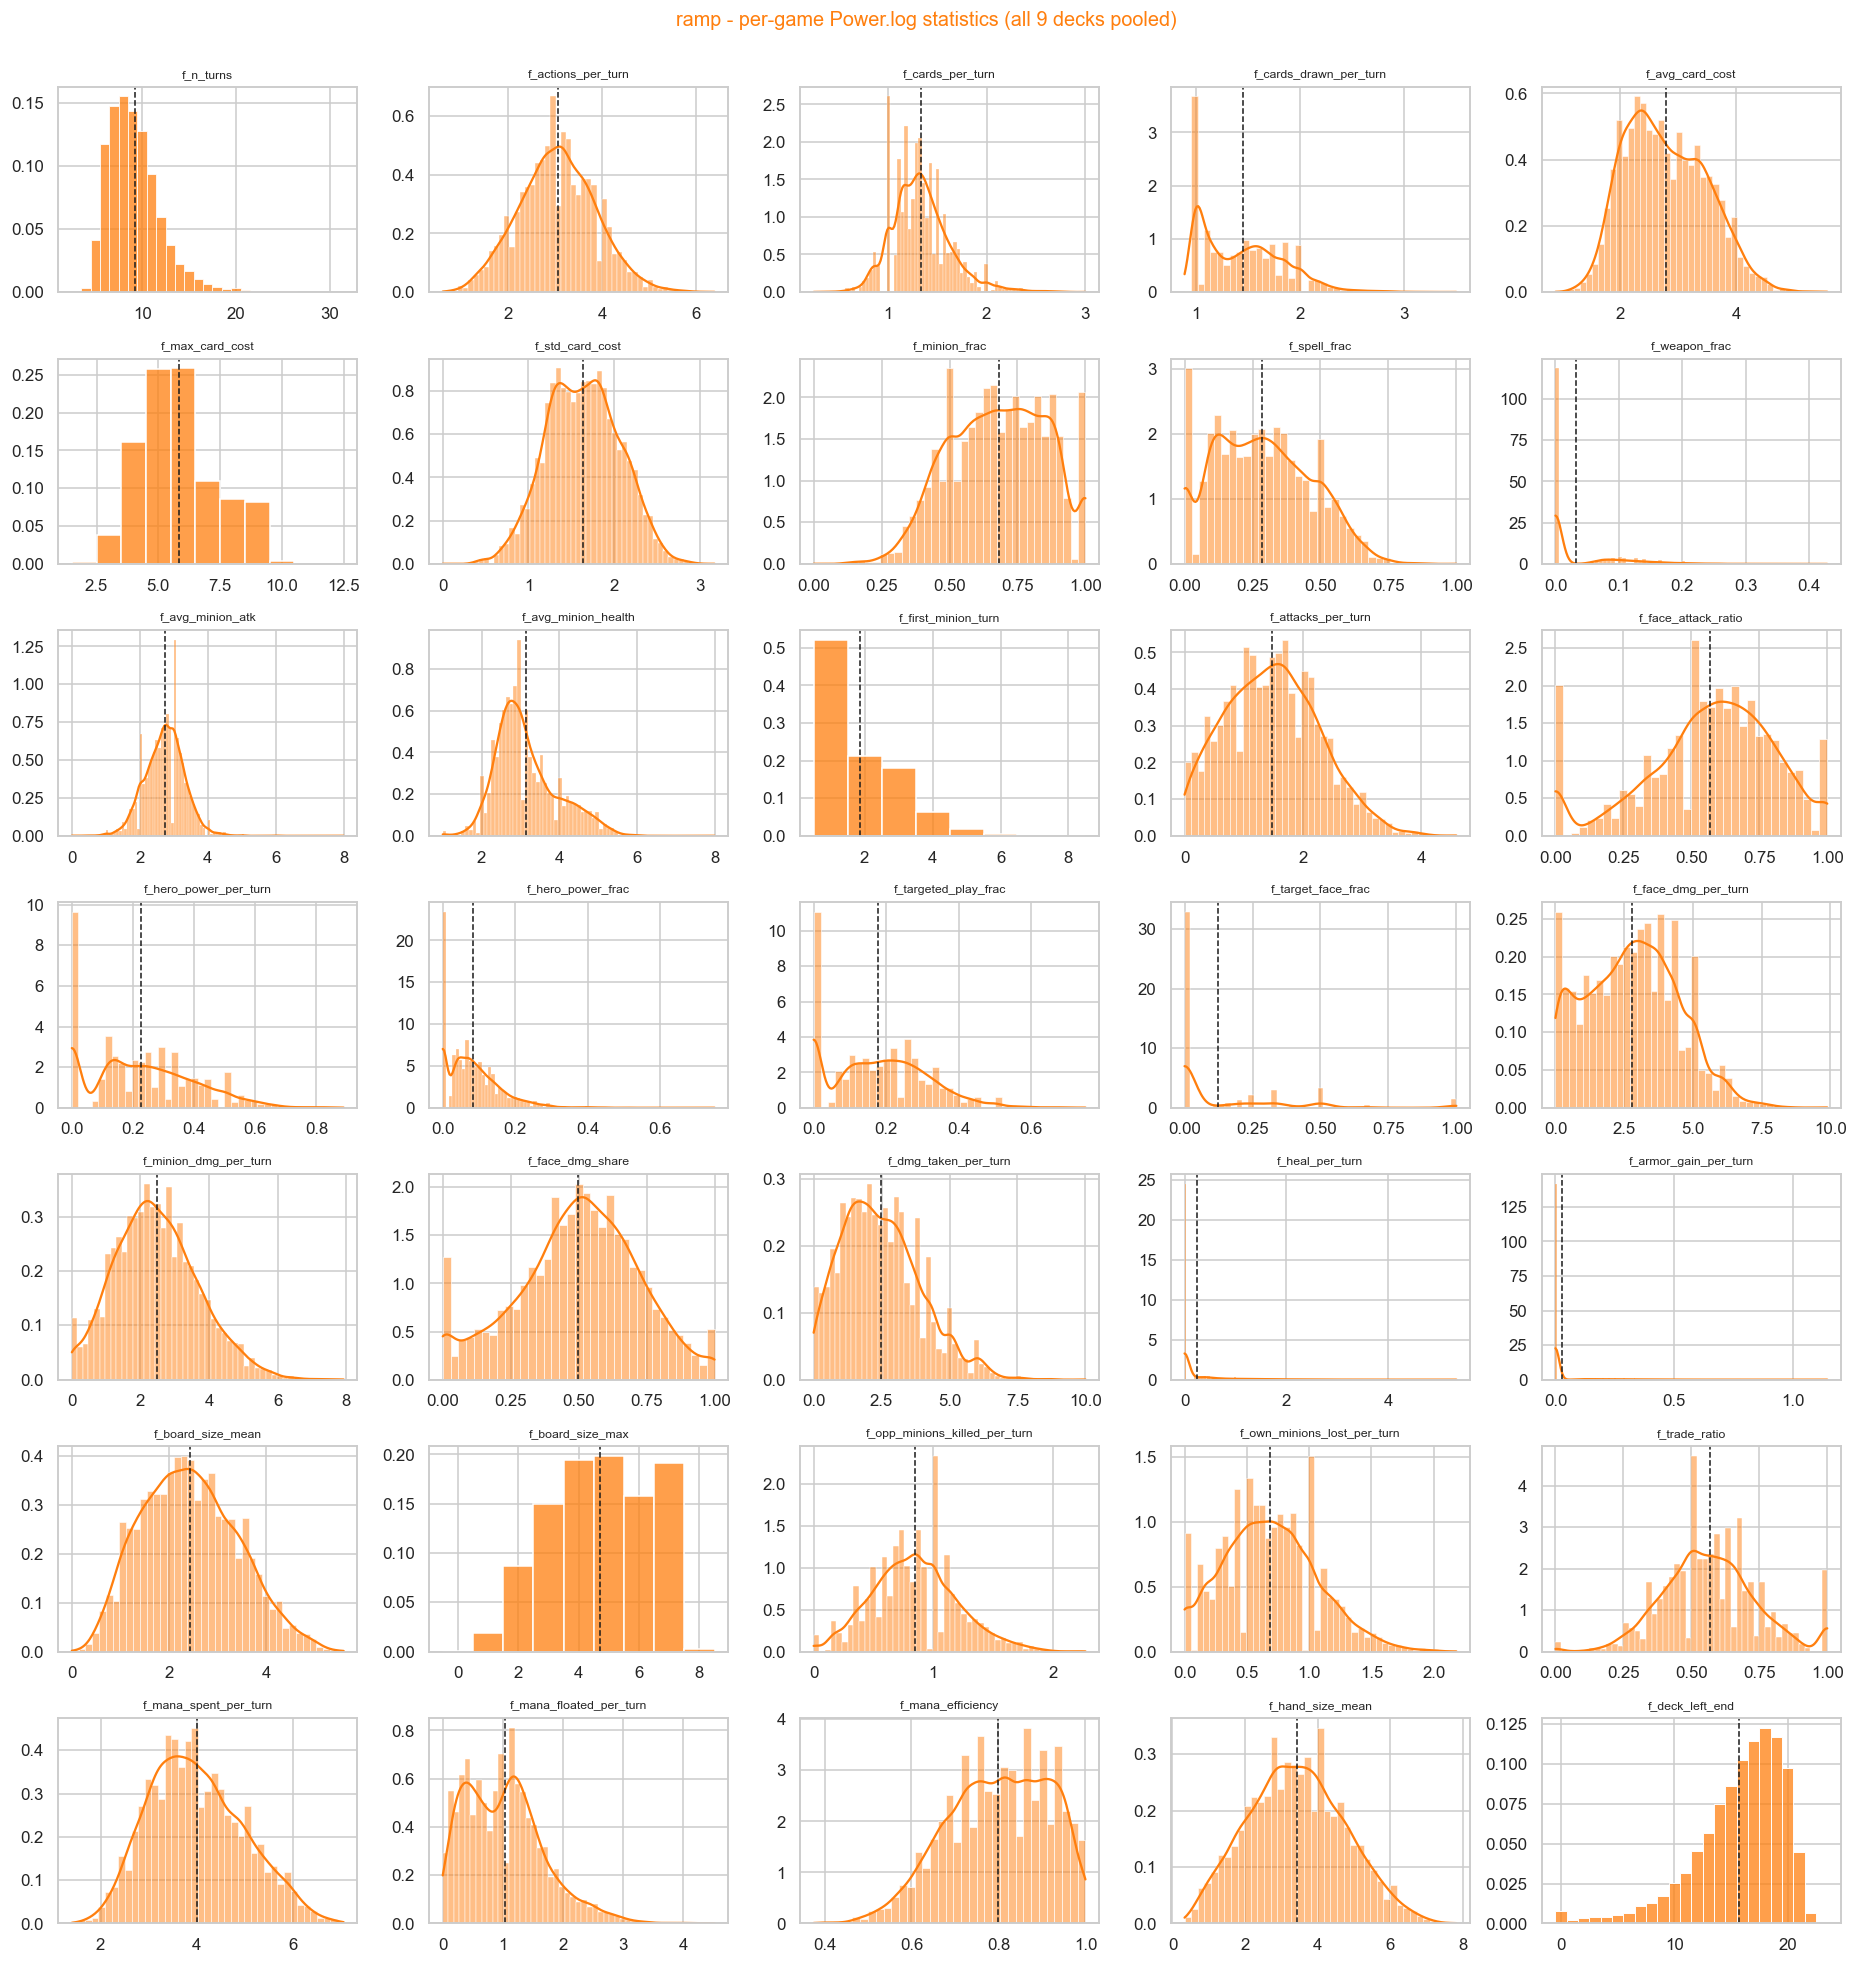

In [7]:
show_style("ramp")

## 3 - Overlaid distributions + the style fingerprints

All 5 styles' KDEs share one axis per statistic: where the coloured curves pull apart the statistic carries play-style signal, where they overlap it does not. The heatmap is the multivariate fingerprint - each style's mean vector, z-scored across the 5 styles.

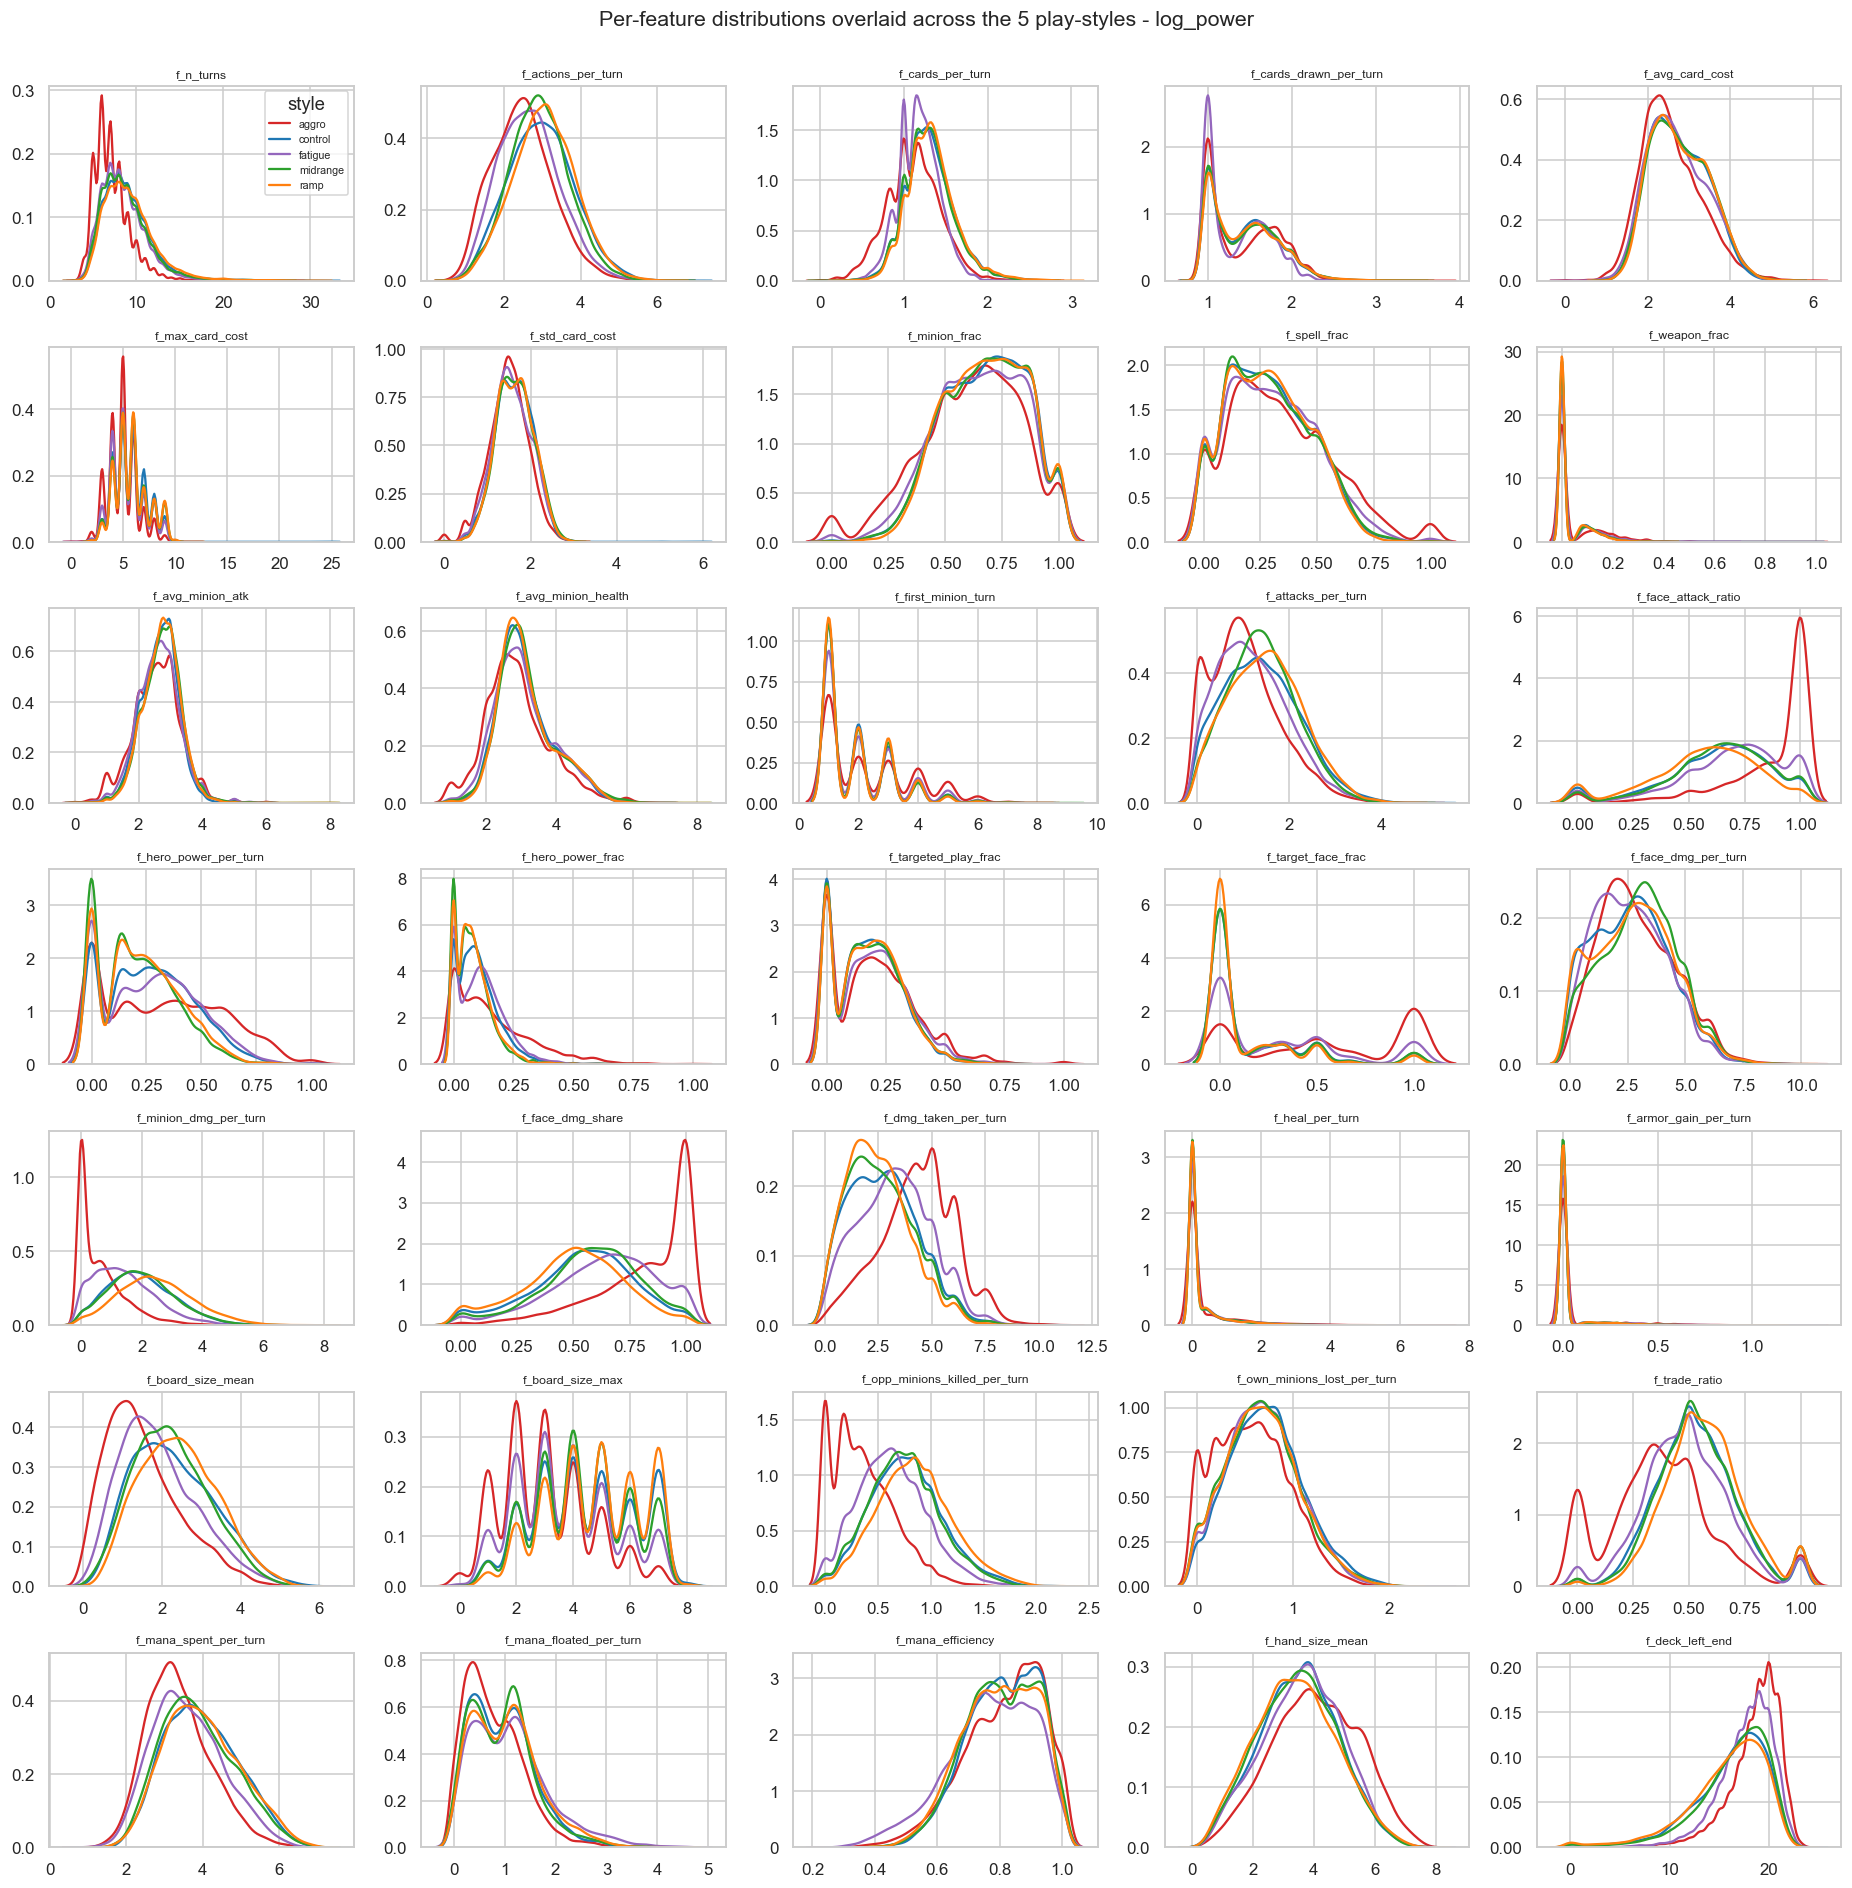

,f_n_turns,f_actions_per_turn,f_cards_per_turn,f_cards_drawn_per_turn,f_avg_card_cost,f_max_card_cost,f_std_card_cost,f_minion_frac,f_spell_frac,f_weapon_frac,...,f_board_size_mean,f_board_size_max,f_opp_minions_killed_per_turn,f_own_minions_lost_per_turn,f_trade_ratio,f_mana_spent_per_turn,f_mana_floated_per_turn,f_mana_efficiency,f_hand_size_mean,f_deck_left_end
style,,,,,,,,,,,,,,,,,,,,,
aggro,7.165,2.487,1.118,1.424,2.569,4.954,1.495,0.612,0.337,0.051,...,1.517,3.043,0.354,0.569,0.376,3.369,0.789,0.814,4.071,18.575
control,8.959,2.977,1.314,1.440,2.754,5.734,1.624,0.677,0.289,0.034,...,2.299,4.416,0.770,0.723,0.530,3.983,0.957,0.810,3.524,16.058
fatigue,8.459,2.663,1.184,1.345,2.717,5.464,1.581,0.656,0.303,0.041,...,1.909,3.723,0.629,0.687,0.488,3.611,1.119,0.770,3.634,17.682
midrange,8.737,2.919,1.304,1.442,2.786,5.790,1.644,0.676,0.291,0.033,...,2.230,4.316,0.746,0.677,0.542,3.886,0.958,0.806,3.471,16.403
ramp,9.199,3.050,1.335,1.446,2.786,5.837,1.637,0.681,0.287,0.032,...,2.435,4.715,0.845,0.684,0.570,4.000,1.029,0.799,3.424,15.712


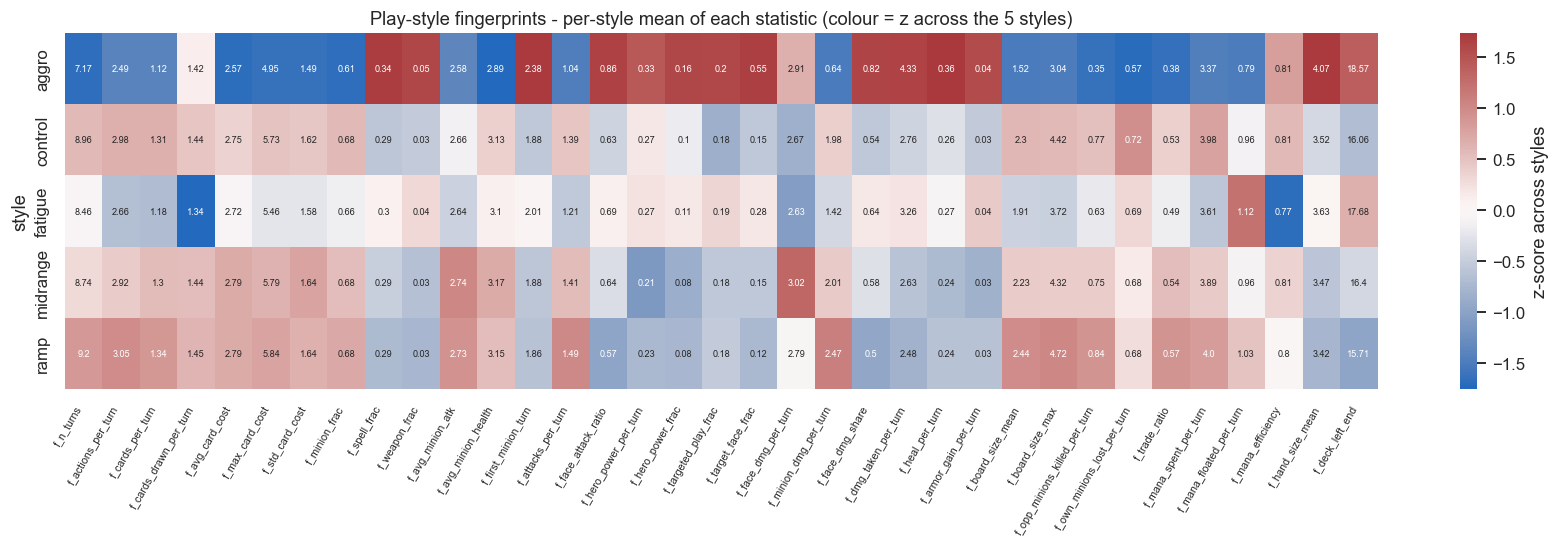

In [8]:
nrow, ncol = _grid_shape(len(FEATURES))
fig, axes = plt.subplots(nrow, ncol, figsize=(3.4 * ncol, 2.5 * nrow)); axes = np.atleast_1d(axes).ravel()
for ax, col in zip(axes, FEATURES):
    kind = kind_of(col)
    for st in STYLE_ORDER:
        s = df.loc[df["style"] == st, col].dropna()
        if s.nunique() > 1:
            sns.kdeplot(s.clip(0, 1) if kind == "clip01" else s, ax=ax,
                        color=STYLE_COLORS[st], lw=1.5, label=st, warn_singular=False)
    ax.set_title(col, fontsize=8); ax.set_xlabel(""); ax.set_ylabel("")
for ax in axes[len(FEATURES):]:
    ax.axis("off")
axes[0].legend(title="style", fontsize=7)
fig.suptitle("Per-feature distributions overlaid across the 5 play-styles - log_power", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.98]); plt.show()

# per-style fingerprint: mean of each feature, z-scored across the 5 styles
mean_tbl = df.groupby("style", observed=True)[FEATURES].mean().reindex(STYLE_ORDER)
z = (mean_tbl - mean_tbl.mean()) / mean_tbl.std()
display(mean_tbl.round(3))
fig, ax = plt.subplots(figsize=(max(11, 0.55 * len(FEATURES)), 4.2))
sns.heatmap(z, annot=mean_tbl.round(2), fmt="", cmap="vlag", center=0, ax=ax,
            cbar_kws={"label": "z-score across styles"}, annot_kws={"fontsize": 6})
ax.set_title("Play-style fingerprints - per-style mean of each statistic (colour = z across the 5 styles)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=60, ha="right", fontsize=7)
plt.show()

### 3b - Deck sensitivity - a preview of SS 8-9

The question that decides the whole study: **does each statistic order the 5 styles the same way on every deck?** One thin line per deck, black dashed = the mean profile. **Parallel** lines mean the style signal survives a change of deck; **crossing** lines mean the statistic is measuring the deck as much as the player - which is exactly what the LODO / LOAO tests will punish.

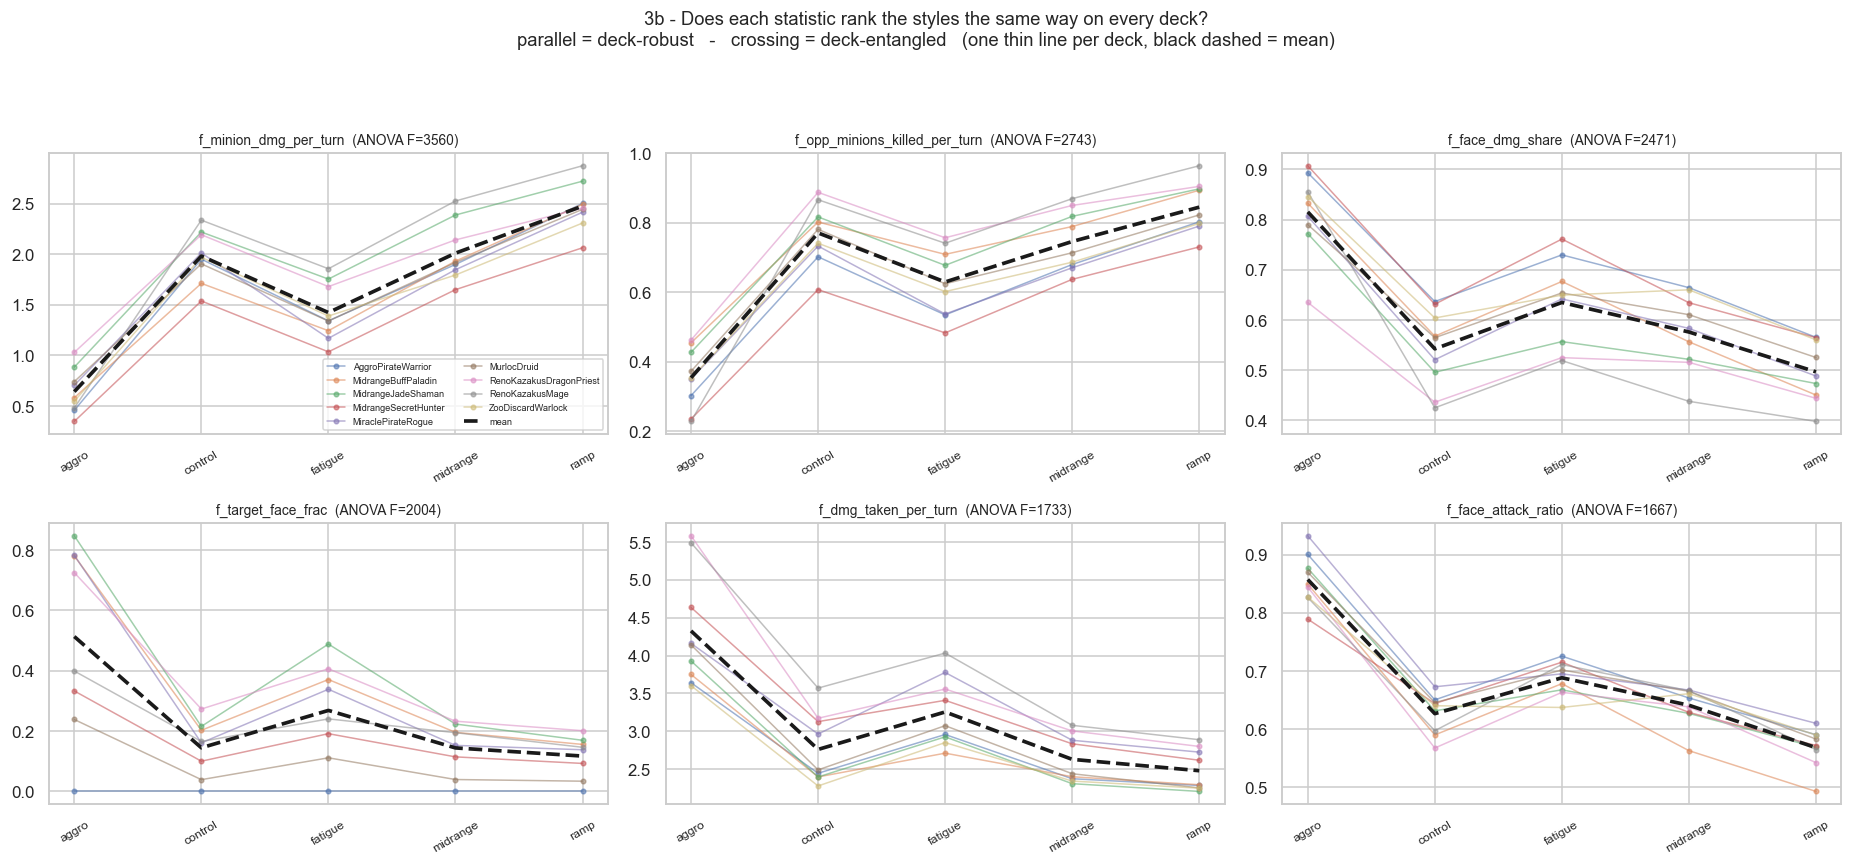

,"ANOVA F (style separation, decks pooled)"
f_minion_dmg_per_turn,3560.0
f_opp_minions_killed_per_turn,2743.0
f_face_dmg_share,2471.1
f_target_face_frac,2003.7
f_dmg_taken_per_turn,1732.8
f_face_attack_ratio,1666.7
f_board_size_max,1277.2
f_trade_ratio,1162.9
f_board_size_mean,1143.1
f_deck_left_end,990.7


In [9]:
# Does each statistic rank the 5 styles the SAME way on every deck?
# parallel lines = deck-robust style signal   |   crossing lines = deck-entangled
from scipy.stats import f_oneway

def anova_F(col):
    groups = [df.loc[df["style"] == s, col].dropna().values for s in STYLE_ORDER]
    groups = [g for g in groups if len(g) > 1]
    if len(groups) < 2:
        return 0.0
    try:
        return float(f_oneway(*groups).statistic)
    except Exception:
        return 0.0

Fs = pd.Series({c: anova_F(c) for c in FEATURES}).sort_values(ascending=False)
top = list(Fs.head(6).index)

fig, axes = plt.subplots(2, 3, figsize=(17, 8)); axes = axes.ravel()
for ax, col in zip(axes, top):
    piv = df.pivot_table(index="style", columns="deck", values=col, observed=True).reindex(STYLE_ORDER)
    for deck in piv.columns:
        ax.plot(range(len(STYLE_ORDER)), piv[deck].values, marker="o", ms=3, lw=1, alpha=.55, label=deck)
    ax.plot(range(len(STYLE_ORDER)), piv.mean(axis=1).values, "k--", lw=2.4, label="mean")
    ax.set_xticks(range(len(STYLE_ORDER))); ax.set_xticklabels(STYLE_ORDER, rotation=30, fontsize=8)
    ax.set_title(f"{col}  (ANOVA F={Fs[col]:.0f})", fontsize=9)
axes[0].legend(fontsize=6, ncol=2)
fig.suptitle("3b - Does each statistic rank the styles the same way on every deck?\n"
             "parallel = deck-robust   -   crossing = deck-entangled   "
             "(one thin line per deck, black dashed = mean)", fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.93]); plt.show()

display(Fs.head(12).to_frame("ANOVA F (style separation, decks pooled)").round(1))

## 4 - Feature matrix

Stack the per-game statistics into `X` (median-imputed, then z-scored) with `y` = the true style. Everything from SS 5 on reads this matrix.

In [10]:
from sklearn.preprocessing import StandardScaler

X_raw = df[FEATURES].copy()
X_raw = X_raw.fillna(X_raw.median())
y = styles_of(df)
scaler = StandardScaler().fit(X_raw.values)
X = scaler.transform(X_raw.values)
print(f"feature matrix: {X.shape}   ({len(FEATURES)} simple Power.log statistics)")
print("features:", ", ".join(FEATURES))

feature matrix: (40497, 35)   (35 simple Power.log statistics)
features: f_n_turns, f_actions_per_turn, f_cards_per_turn, f_cards_drawn_per_turn, f_avg_card_cost, f_max_card_cost, f_std_card_cost, f_minion_frac, f_spell_frac, f_weapon_frac, f_avg_minion_atk, f_avg_minion_health, f_first_minion_turn, f_attacks_per_turn, f_face_attack_ratio, f_hero_power_per_turn, f_hero_power_frac, f_targeted_play_frac, f_target_face_frac, f_face_dmg_per_turn, f_minion_dmg_per_turn, f_face_dmg_share, f_dmg_taken_per_turn, f_heal_per_turn, f_armor_gain_per_turn, f_board_size_mean, f_board_size_max, f_opp_minions_killed_per_turn, f_own_minions_lost_per_turn, f_trade_ratio, f_mana_spent_per_turn, f_mana_floated_per_turn, f_mana_efficiency, f_hand_size_mean, f_deck_left_end


## 5 - Per-game clustering - the honest baseline

Project the per-game points to 2-D (**PCA**, **t-SNE**) coloured by true style, then run **KMeans with k = 5** and score the clusters against the true styles with **ARI**. This is the hardest setting in the notebook: one game, 9 decks pooled, a random opponent each time.

Per-game unsupervised clustering vs the 5 true styles (all 9 decks pooled)
  KMeans(k=5): ARI = 0.038   (chance line 0.20, perfect = 1.00)


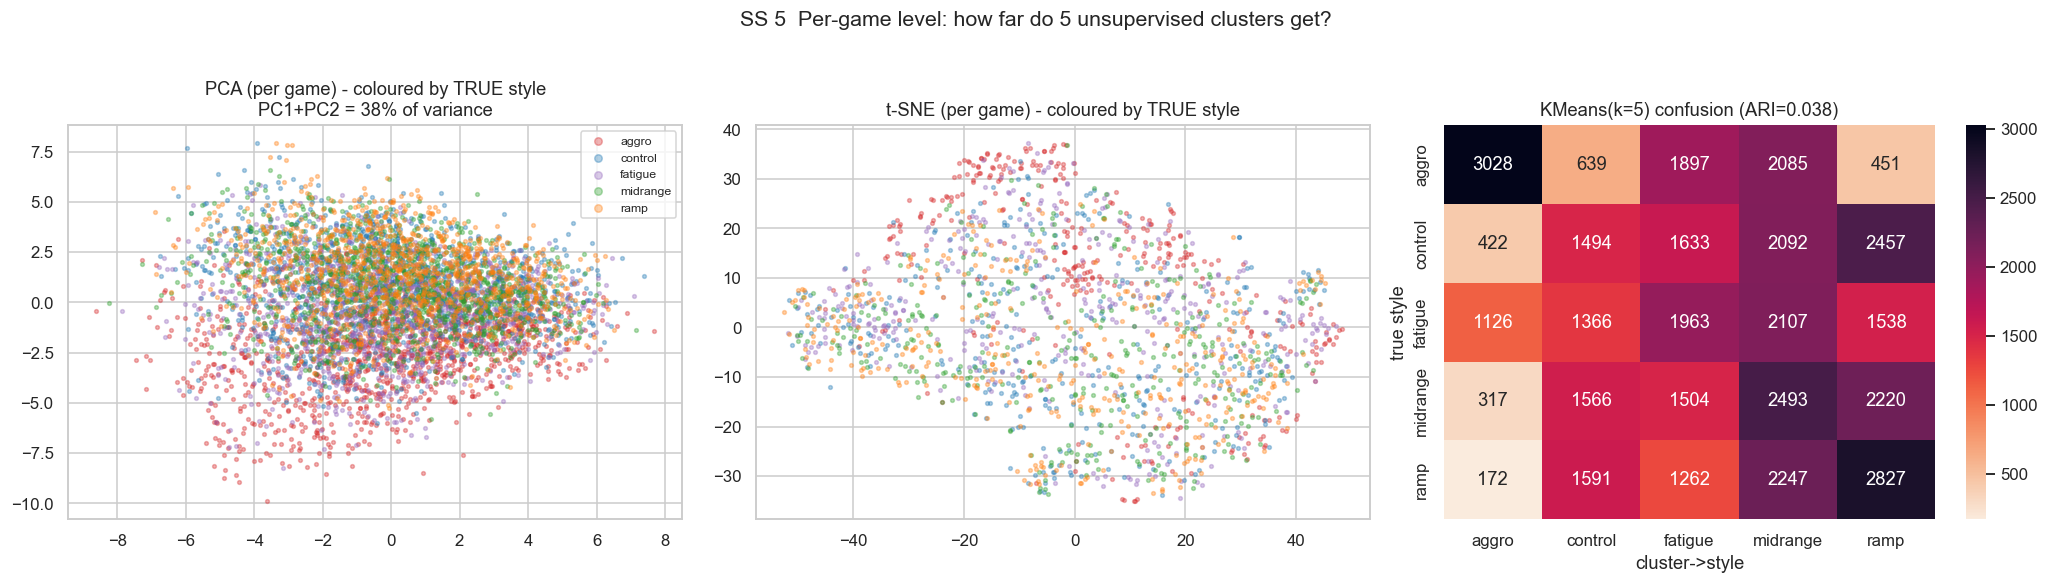

In [11]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
from scipy.optimize import linear_sum_assignment

# MODEL POLICY (whole notebook): unsupervised = KMeans(k=5), supervised = LDA, metric = ARI.
K = 5

def cluster_confusion(true_lab, clab, order=STYLE_ORDER):
    """Hungarian-map cluster ids onto styles so the confusion matrix is readable.
    (ARI itself is permutation-invariant, so the mapping never changes the score.)"""
    k = len(order)
    M = pd.crosstab(pd.Series(true_lab, name="style"), pd.Series(clab, name="cluster"))
    M = M.reindex(index=order).reindex(columns=range(k), fill_value=0).fillna(0)
    r, c = linear_sum_assignment(-M.values)
    col_to_style = {c[i]: order[r[i]] for i in range(len(r))}
    mapped = pd.Series(clab).map(lambda x: col_to_style.get(x, x)).values
    cm = pd.crosstab(pd.Series(true_lab, name="true style"),
                     pd.Series(mapped, name="cluster->style")).reindex(index=order, columns=order, fill_value=0)
    return cm, mapped

rng = np.random.default_rng(0)
pca = PCA(n_components=2, random_state=0).fit(X)
P = pca.transform(X)
sub  = rng.choice(len(X), size=min(1800, len(X)), replace=False)   # t-SNE subsample (speed)
psub = rng.choice(len(X), size=min(6000, len(X)), replace=False)   # scatter subsample (40k overplots)
T = TSNE(n_components=2, init="pca", perplexity=40, random_state=0).fit_transform(X[sub])

km_lab = KMeans(K, n_init=10, random_state=0).fit_predict(X)
ari_km = adjusted_rand_score(y, km_lab)
print("Per-game unsupervised clustering vs the 5 true styles (all 9 decks pooled)")
print(f"  KMeans(k=5): ARI = {ari_km:.3f}   (chance line 0.20, perfect = 1.00)")

fig, ax = plt.subplots(1, 3, figsize=(19, 5.4))
for st in STYLE_ORDER:
    m  = (y[psub] == st); ax[0].scatter(P[psub][m, 0], P[psub][m, 1], s=6, alpha=.35, color=STYLE_COLORS[st], label=st)
    ms = (y[sub]  == st); ax[1].scatter(T[ms, 0], T[ms, 1], s=6, alpha=.35, color=STYLE_COLORS[st], label=st)
ax[0].set_title(f"PCA (per game) - coloured by TRUE style\nPC1+PC2 = {pca.explained_variance_ratio_[:2].sum():.0%} of variance")
ax[0].legend(fontsize=8, markerscale=2)
ax[1].set_title("t-SNE (per game) - coloured by TRUE style")
cm, _ = cluster_confusion(y, km_lab)
sns.heatmap(cm, annot=True, fmt="d", cmap="rocket_r", ax=ax[2])
ax[2].set_title(f"KMeans(k=5) confusion (ARI={ari_km:.3f})")
for a in ax[:2]:
    a.set_xlabel(""); a.set_ylabel("")
fig.suptitle("SS 5  Per-game level: how far do 5 unsupervised clusters get?", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()

### 5b - Is the signal there at all? (supervised check)

Same matrix, **supervised LDA** with 5-fold cross-validated predictions, scored with the same **ARI**. An ARI clearly above 0 means the per-game signal is real, only noisy - the gap to SS 5 is what labels buy you. Because `X` is z-scored the LDA coefficients are comparable across features, so the bar chart (mean |coefficient| over the 5 classes) is the LDA's feature-importance ranking.

LDA 5-fold CV:  ARI = 0.118   (accuracy 0.411, majority baseline 0.200)


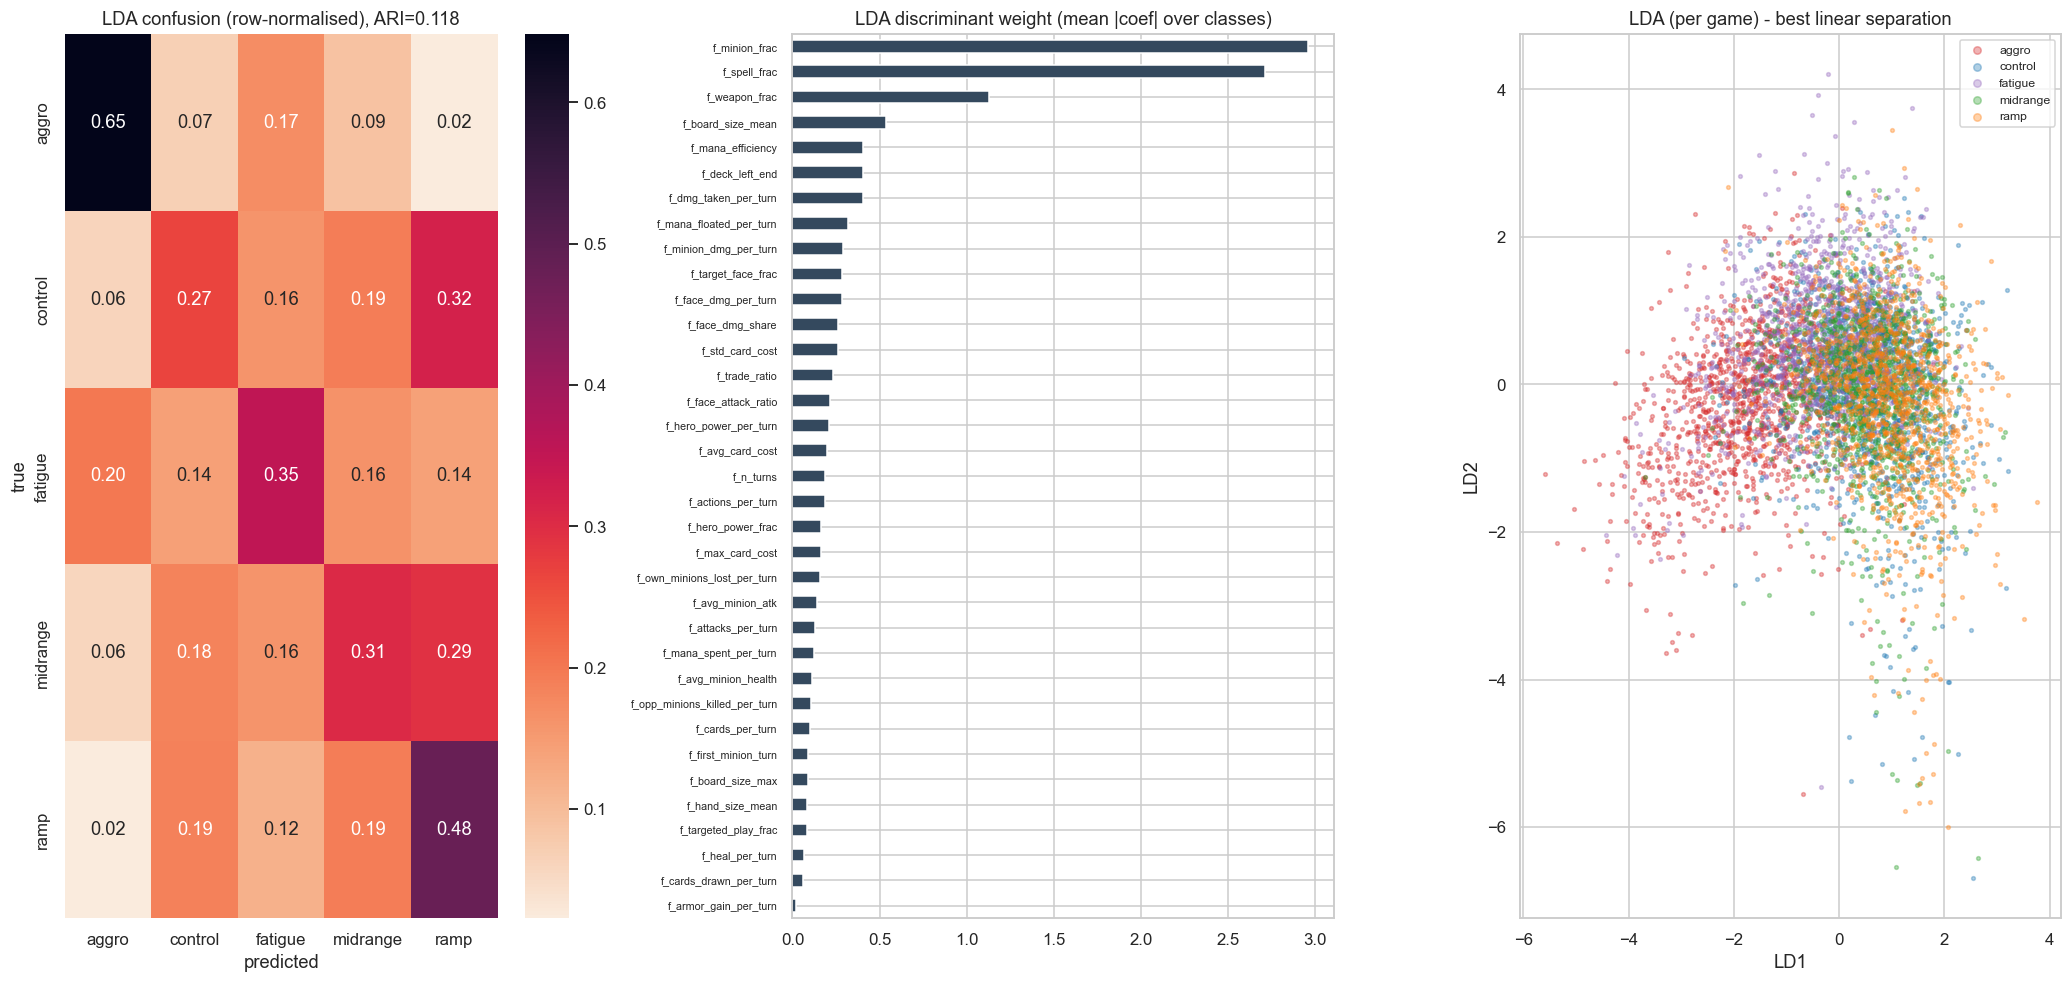

In [12]:
from sklearn.model_selection import cross_val_predict
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import confusion_matrix

lda = LinearDiscriminantAnalysis()
pred = cross_val_predict(lda, X, y, cv=5, n_jobs=-1)
ari_lda = adjusted_rand_score(y, pred)
acc_lda = (pred == y).mean()
print(f"LDA 5-fold CV:  ARI = {ari_lda:.3f}   (accuracy {acc_lda:.3f}, majority baseline 0.200)")

fitted = LinearDiscriminantAnalysis(n_components=2).fit(X, y)
# X is z-scored, so |coef| is comparable across features; the mean over the 5
# one-vs-rest rows is the LDA analogue of a feature-importance ranking.
imp = pd.Series(np.abs(fitted.coef_).mean(axis=0), index=FEATURES).sort_values()
L = fitted.transform(X)

fig, ax = plt.subplots(1, 3, figsize=(19, max(5.6, 0.26 * len(FEATURES))))
cm = confusion_matrix(y, pred, labels=STYLE_ORDER, normalize="true")
sns.heatmap(pd.DataFrame(cm, index=STYLE_ORDER, columns=STYLE_ORDER), annot=True, fmt=".2f",
            cmap="rocket_r", ax=ax[0])
ax[0].set_title(f"LDA confusion (row-normalised), ARI={ari_lda:.3f}")
ax[0].set_ylabel("true"); ax[0].set_xlabel("predicted")
imp.plot.barh(ax=ax[1], color="#34495e"); ax[1].set_title("LDA discriminant weight (mean |coef| over classes)")
ax[1].tick_params(axis="y", labelsize=7)
Lp, yp = L[psub], y[psub]
for st in STYLE_ORDER:
    m = (yp == st); ax[2].scatter(Lp[m, 0], Lp[m, 1], s=6, alpha=.35, color=STYLE_COLORS[st], label=st)
ax[2].set_title("LDA (per game) - best linear separation"); ax[2].legend(fontsize=8, markerscale=2)
ax[2].set_xlabel("LD1"); ax[2].set_ylabel("LD2")
fig.tight_layout(); plt.show()

## 6 - Aggregating games: ARI vs N

A play-style is a *distribution over games*, not a single game. Characterise each style by the mean of **N** random games and re-run both models: **KMeans** on all fingerprints (unsupervised) and an **LDA** trained on a disjoint half of the games and tested on fingerprints of held-out games (supervised). Both are scored by ARI, so the two curves are directly comparable.

Smallest N (games pooled into one fingerprint) to reach ARI:
  KMeans ARI   >=0.80: N = 70    >=0.90: N = 90
  LDA ARI      >=0.80: N = 25    >=0.90: N = 50


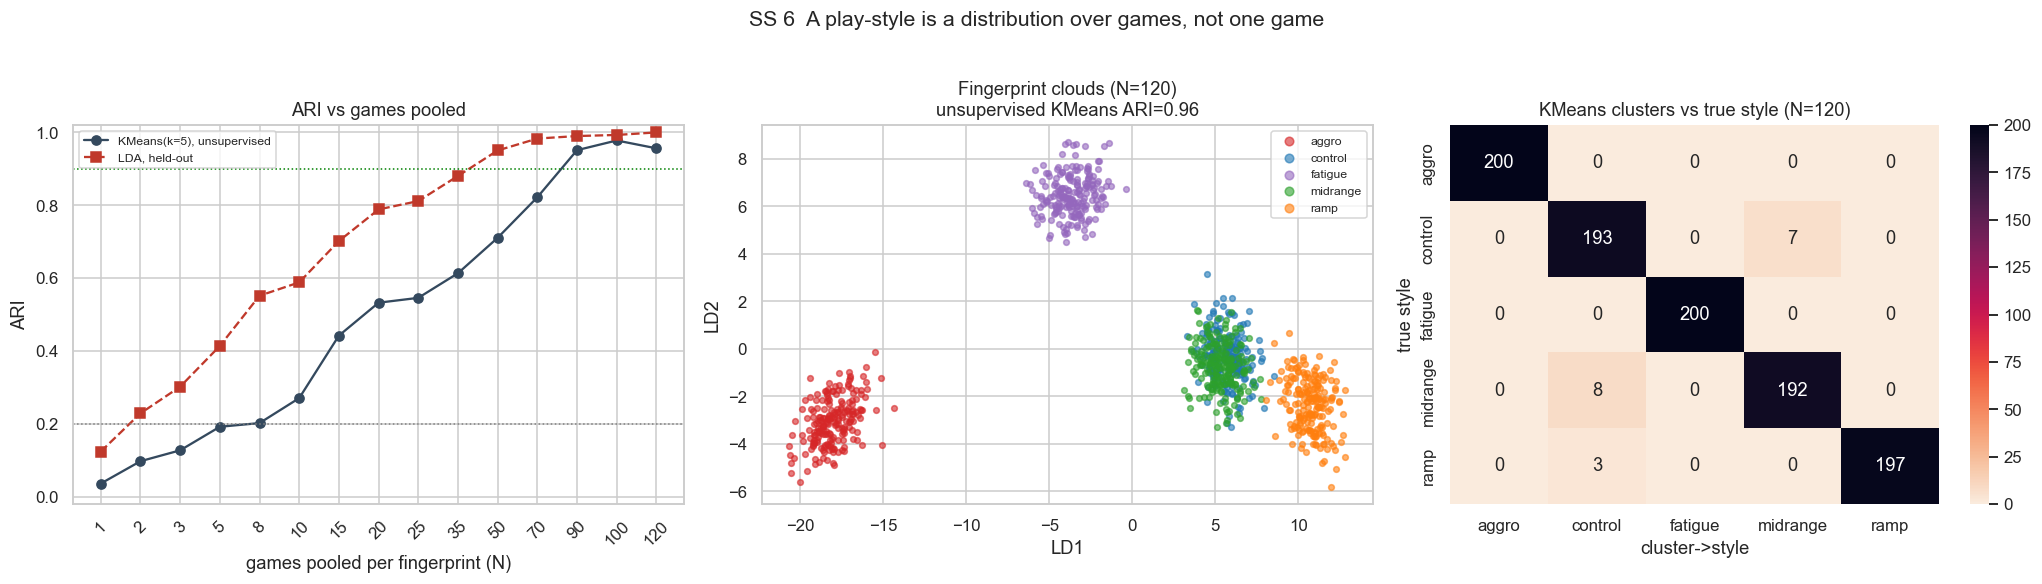

,KMeans ARI,LDA ARI,aggro,control,fatigue,midrange,ramp
N,,,,,,,
1,0.036,0.124,0.698,0.274,0.376,0.316,0.402
2,0.097,0.229,0.794,0.350,0.550,0.436,0.518
3,0.127,0.302,0.864,0.402,0.628,0.484,0.586
5,0.192,0.414,0.924,0.512,0.800,0.550,0.592
8,0.202,0.552,0.968,0.608,0.896,0.640,0.738
10,0.270,0.588,0.972,0.658,0.940,0.662,0.726
15,0.442,0.702,0.994,0.734,0.974,0.770,0.818
20,0.532,0.789,0.998,0.786,0.986,0.852,0.900
25,0.546,0.811,1.000,0.812,0.992,0.896,0.880


In [13]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# --- held-out 50/50 split within each style (disjoint games, decks pooled) ---
def heldout_split(frame, feats, seed=1):
    rng = np.random.default_rng(seed)
    G = frame.copy(); G[feats] = G[feats].fillna(G[feats].median())
    tr_idx, te_idx = [], []
    for st in STYLE_ORDER:
        idx = G.index[G["style"] == st].to_numpy().copy(); rng.shuffle(idx)
        h = len(idx) // 2; tr_idx += list(idx[:h]); te_idx += list(idx[h:])
    sc = StandardScaler().fit(G.loc[tr_idx, feats].values)
    return (sc.transform(G.loc[tr_idx, feats].values), styles_of(G.loc[tr_idx]),
            sc.transform(G.loc[te_idx, feats].values), styles_of(G.loc[te_idx]))

def fps(by, N, reps, seed):
    """`reps` fingerprints per style, each the mean of N games drawn with replacement."""
    r = np.random.default_rng(seed); Xs, ys = [], []
    for s in STYLE_ORDER:
        a = by[s]
        if not len(a):
            continue
        for _ in range(reps):
            Xs.append(a[r.integers(0, len(a), N)].mean(0)); ys.append(s)
    return np.array(Xs), np.array(ys, dtype=object)

Ns = [1, 2, 3, 5, 8, 10, 15, 20, 25, 35, 50, 70, 90, 100, 120]
allby = {s: X[y == s] for s in STYLE_ORDER}
Xtr, ytr, Xte, yte = heldout_split(df, FEATURES)
trby = {s: Xtr[ytr == s] for s in STYLE_ORDER}
teby = {s: Xte[yte == s] for s in STYLE_ORDER}

rows = []
for N in Ns:
    Xb, yb = fps(allby, N, 200, 0)                                   # unsupervised
    ari_u = adjusted_rand_score(yb, KMeans(K, n_init=10, random_state=0).fit_predict(Xb))
    Xa, ya = fps(trby, N, 500, 10); Xc, yc = fps(teby, N, 500, 20)   # supervised, held out
    p = LinearDiscriminantAnalysis().fit(Xa, ya).predict(Xc)
    row = {"N": N, "KMeans ARI": ari_u, "LDA ARI": adjusted_rand_score(yc, p)}
    for s in STYLE_ORDER:                                            # ARI has no per-class form
        row[s] = (p[yc == s] == s).mean()
    rows.append(row)
sweep = pd.DataFrame(rows).set_index("N")

def first_N(col, thr):
    hit = sweep.index[sweep[col] >= thr]
    return int(hit[0]) if len(hit) else f">{Ns[-1]}"
print("Smallest N (games pooled into one fingerprint) to reach ARI:")
for col in ("KMeans ARI", "LDA ARI"):
    print(f"  {col:11s}  >=0.80: N = {first_N(col, 0.80)}    >=0.90: N = {first_N(col, 0.90)}")

Xb, yb = fps(allby, 120, 200, 0)
labb = KMeans(K, n_init=10, random_state=0).fit_predict(Xb)
ari_b = adjusted_rand_score(yb, labb)
Lb = LinearDiscriminantAnalysis(n_components=2).fit(Xb, yb).transform(Xb)

fig, ax = plt.subplots(1, 3, figsize=(19, 5.4)); xs = range(len(Ns))
ax[0].plot(xs, sweep["KMeans ARI"], "o-", color="#34495e", label="KMeans(k=5), unsupervised")
ax[0].plot(xs, sweep["LDA ARI"], "s--", color="#c0392b", label="LDA, held-out")
ax[0].axhline(0.9, color="green", ls=":", lw=1); ax[0].axhline(CHANCE, color="gray", ls=":", lw=1)
ax[0].set_xticks(list(xs)); ax[0].set_xticklabels(Ns, rotation=45); ax[0].set_ylim(-0.02, 1.02)
ax[0].set_xlabel("games pooled per fingerprint (N)"); ax[0].set_ylabel("ARI")
ax[0].set_title("ARI vs games pooled"); ax[0].legend(fontsize=8)
for st in STYLE_ORDER:
    m = (yb == st); ax[1].scatter(Lb[m, 0], Lb[m, 1], s=14, alpha=.6, color=STYLE_COLORS[st], label=st)
ax[1].set_title(f"Fingerprint clouds (N=120)\nunsupervised KMeans ARI={ari_b:.2f}")
ax[1].legend(fontsize=8, markerscale=1.5); ax[1].set_xlabel("LD1"); ax[1].set_ylabel("LD2")
cmb, _ = cluster_confusion(yb, labb)
sns.heatmap(cmb, annot=True, fmt="d", cmap="rocket_r", ax=ax[2])
ax[2].set_title("KMeans clusters vs true style (N=120)")
fig.suptitle("SS 6  A play-style is a distribution over games, not one game", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()

display(sweep.style.format("{:.3f}")
        .background_gradient(cmap="rocket_r", subset=["KMeans ARI", "LDA ARI"] + STYLE_ORDER)
        .set_caption("ARI of an N-game fingerprint (KMeans unsupervised / LDA held-out) "
                     "+ per-style recall of the LDA"))

## 7 - Within-deck

Everything above pooled 9 decks, so a model could score well by reading the **deck**. Here each deck is analysed **on its own**: all 5 styles, one deck, so the deck is constant and cannot be a confound. LDA is 5-fold cross-validated inside the deck; KMeans (k=5) is fitted on that deck's games. This is the ceiling the cross-deck tests are measured against.

Within-deck ARI - only games of ONE deck, so the deck cannot be a confound


,family,n games,LDA ARI (5-fold),KMeans ARI (k=5)
MurlocDruid,aggro,4500,0.285,0.105
MidrangeJadeShaman,midrange,4499,0.268,0.053
RenoKazakusDragonPriest,highlander_control,4500,0.239,0.078
RenoKazakusMage,highlander_control,4498,0.235,0.107
MidrangeSecretHunter,midrange,4500,0.225,0.121
MiraclePirateRogue,combo_tempo,4500,0.218,0.077
ZooDiscardWarlock,aggro,4500,0.196,0.078
MidrangeBuffPaladin,midrange,4500,0.164,0.059
AggroPirateWarrior,aggro,4500,0.158,0.058


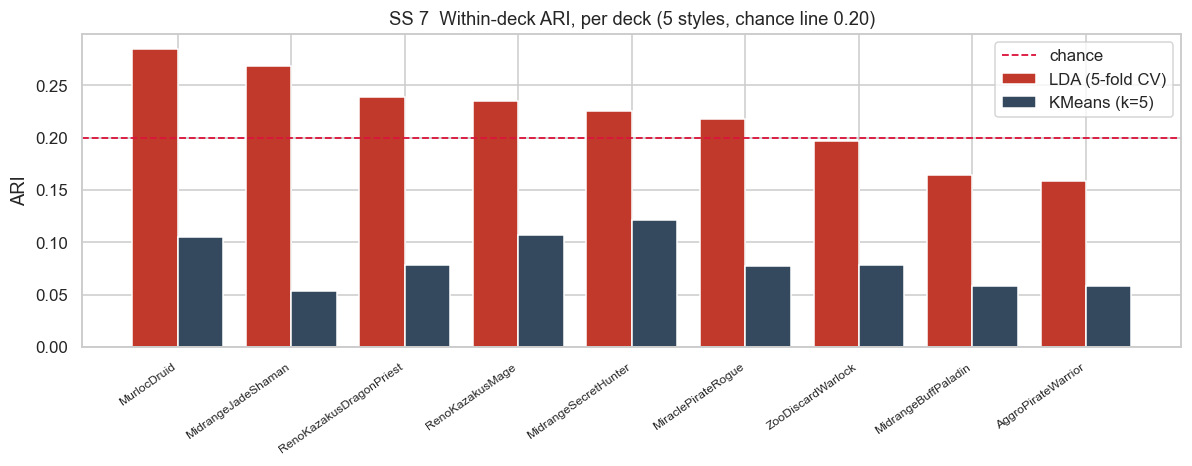

mean within-deck ARI:  LDA 0.221   KMeans 0.082


In [14]:
# ===== SS 7 - WITHIN-DECK: fit and score inside one deck at a time =====
from sklearn.model_selection import cross_val_predict

def _xy(frame, feats, fill_from=None):
    med = (frame if fill_from is None else fill_from)[feats].median()
    return frame[feats].fillna(med).fillna(0.0).values, styles_of(frame)

within = {}
for deck, g in df.groupby("deck", observed=True):
    Xg, yg = _xy(g, FEATURES)
    Xg = StandardScaler().fit_transform(Xg)
    p = cross_val_predict(LinearDiscriminantAnalysis(), Xg, yg, cv=5, n_jobs=-1)
    within[deck] = {
        "n games": len(g),
        "LDA ARI (5-fold)": adjusted_rand_score(yg, p),
        "KMeans ARI (k=5)": adjusted_rand_score(yg, KMeans(K, n_init=10, random_state=0).fit_predict(Xg)),
    }
within_df = pd.DataFrame(within).T.astype(float).sort_values("LDA ARI (5-fold)", ascending=False)
within_df["family"] = [df.loc[df["deck"] == d, "deck_family"].iloc[0] for d in within_df.index]
print("Within-deck ARI - only games of ONE deck, so the deck cannot be a confound")
display(within_df[["family", "n games", "LDA ARI (5-fold)", "KMeans ARI (k=5)"]]
        .style.format({"n games": "{:.0f}", "LDA ARI (5-fold)": "{:.3f}", "KMeans ARI (k=5)": "{:.3f}"})
        .background_gradient(cmap="rocket_r", subset=["LDA ARI (5-fold)", "KMeans ARI (k=5)"]))

fig, ax = plt.subplots(figsize=(11, 4.4))
w = 0.4; xs = np.arange(len(within_df))
ax.bar(xs - w/2, within_df["LDA ARI (5-fold)"], w, label="LDA (5-fold CV)", color="#c0392b")
ax.bar(xs + w/2, within_df["KMeans ARI (k=5)"], w, label="KMeans (k=5)", color="#34495e")
ax.axhline(CHANCE, color="crimson", ls="--", lw=1.2, label="chance")
ax.set_xticks(xs); ax.set_xticklabels(within_df.index, rotation=35, ha="right", fontsize=8)
ax.set_ylabel("ARI"); ax.set_title("SS 7  Within-deck ARI, per deck (5 styles, chance line 0.20)")
ax.legend(); fig.tight_layout(); plt.show()
print(f"mean within-deck ARI:  LDA {within_df['LDA ARI (5-fold)'].mean():.3f}   "
      f"KMeans {within_df['KMeans ARI (k=5)'].mean():.3f}")

## 8 & 9 - Cross-deck: LODO and LOAO

Now the real question - does the model read the **player** or the **deck**?

* **LODO** (leave-one-deck-out, 9 folds): train on 8 decks, test on the 9th. A sibling deck of the same family stays in training, so this is the *milder* shift.
* **LOAO** (leave-one-archetype-out, 4 folds): hold out a whole deck **family** (`aggro` / `midrange` / `highlander_control` / `combo_tempo`), so nothing resembling the test decks is ever seen in training - the strict test.

For KMeans two readings are reported, because 'transfer' means something different for an unsupervised model:

* **fit on train** - the centroids learned on the training decks are carried over and used to assign the held-out deck's games. This is genuine transfer.
* **fit on held-out** - KMeans is run on the held-out deck's own games. No transfer happens; it is the unsupervised ceiling for that deck, and the gap between the two is the cost of moving centroids across a domain shift.

The per-fold tables score a **single game**. The figure then sweeps all three protocols - **within-deck** (SS 7's ceiling, re-run here as a 50/50 held-out split inside each deck so it uses the same fingerprint protocol as the transfer curves), **LODO** and **LOAO** - over **N**, the number of games pooled into one fingerprint. The **gap between the within-deck curve and the two transfer curves is the deck leakage**, and how fast the transfer curves climb says how many unseen-deck games a fingerprint needs.

> **How different are the 9 decks, really?** (checked against [`decks_v2.py`](../decks_v2.py)) They are **9 different hero classes, one each** - Warrior, Paladin, Shaman, Hunter, Rogue, Druid, Priest, Mage, Warlock - not variants of one archetype. Class cards cannot be shared across classes, so the only possible overlap is neutrals, and it is tiny: card-name Jaccard averages **0.020** across the 36 pairs and peaks at **0.154** for the two Reno highlander decks (8 shared neutral staples: Reno Jackson, Kazakus, Brann, Doomsayer, Dirty Rat, Kabal Courier, Azure Drake, Acidic Swamp Ooze); the runner-up is 0.121 (JadeShaman / MiraclePirateRogue, 4 shared neutrals) and every other pair is <= 0.062. Each deck runs **13-22 cards no other deck runs**. So **LODO is a real domain shift.**
>
> The consequence for **LOAO**: `deck_family` is a *strategic* grouping, not a compositional one. Within-family card overlap (mean 0.026) is barely above across-family (0.020), so the sibling deck that LODO leaves in training was never carrying much of the held-out deck's card pool anyway - which is why LOAO lands so close to LODO below. The grouping is still meaningful in *behaviour* space (mean profile distance 6.06 within family vs 8.46 across, and the three closest deck pairs are all same-family), but it is soft: MiraclePirateRogue / MurlocDruid sit closer than 4 of the 7 same-family pairs. Treat LOAO here as *a second, slightly stricter LODO*, not as a categorically harder test.

LODO - leave-one-DECK-out (train on 8 decks, test on the 9th)


,n test games,LDA ARI,KMeans ARI (fit on train),KMeans ARI (fit on held-out)
AggroPirateWarrior,4500,0.092,0.009,0.065
MidrangeBuffPaladin,4500,0.095,0.037,0.074
MidrangeJadeShaman,4499,0.110,0.037,0.070
MidrangeSecretHunter,4500,0.132,0.098,0.147
MiraclePirateRogue,4500,0.146,0.047,0.069
MurlocDruid,4500,0.204,0.066,0.078
RenoKazakusDragonPriest,4500,0.092,0.016,0.068
RenoKazakusMage,4498,0.164,0.126,0.132
ZooDiscardWarlock,4500,0.105,0.015,0.092



LOAO - leave-one-ARCHETYPE-out (hold out a whole deck family, no sibling deck in training)


,n test games,LDA ARI,KMeans ARI (fit on train),KMeans ARI (fit on held-out)
aggro,13500,0.103,0.019,0.025
combo_tempo,4500,0.146,0.047,0.069
highlander_control,8998,0.108,0.058,0.066
midrange,13499,0.114,0.030,0.042



Headline mean ARI at N = 1, a single game (chance line 0.20):


,within-deck (9),cross-deck LODO (9),cross-family LOAO (4)
LDA,0.221,0.127,0.118
KMeans (fit on train),NaN,0.050,0.039
KMeans (fit on held-out),0.082,0.088,0.050



LDA ARI on N-game fingerprints (chance line 0.20):


,within-deck (9),cross-deck LODO (9),cross-family LOAO (4)
N games pooled,,,
1,0.204,0.114,0.099
2,0.323,0.167,0.137
3,0.406,0.209,0.204
5,0.516,0.256,0.212
8,0.623,0.287,0.316
10,0.674,0.317,0.346
15,0.746,0.385,0.372
20,0.807,0.366,0.445
25,0.855,0.430,0.487


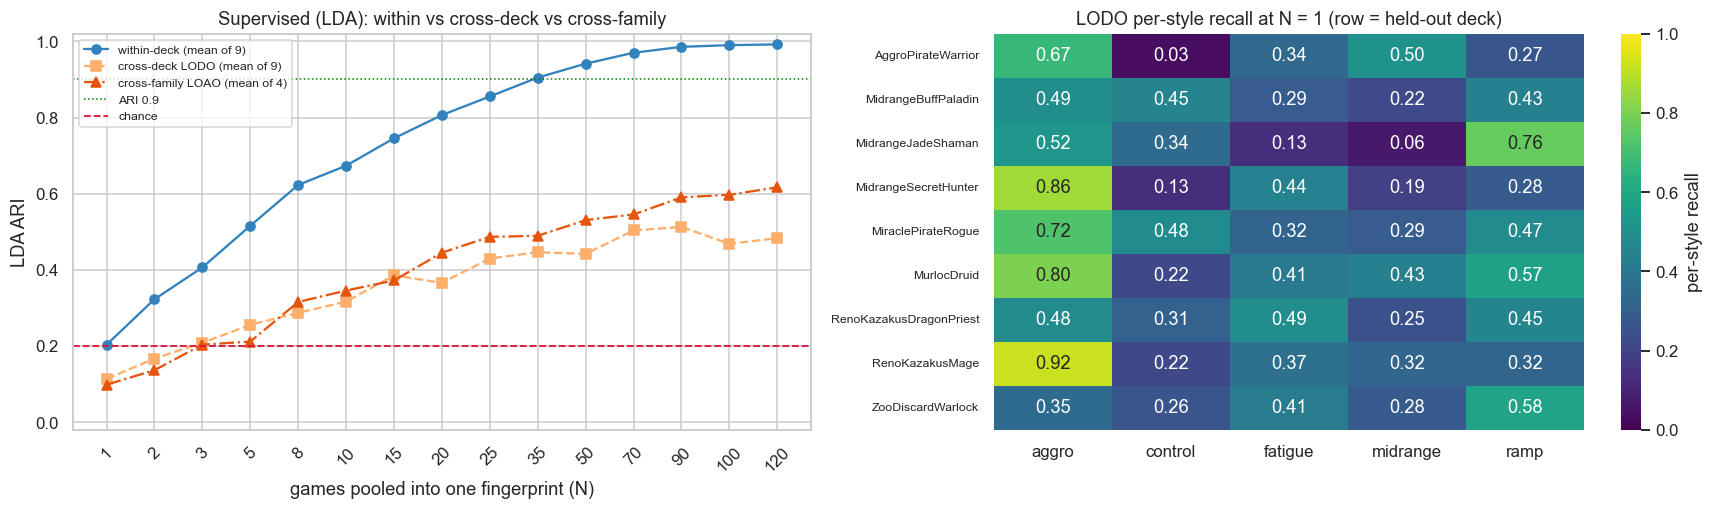

In [15]:
# ===== SS 8-9 - CROSS-DECK: LODO (leave-one-deck-out) and LOAO (leave-one-archetype-out) =====
def transfer(frame, feats, split_col):
    """Train on every group but one, test on the held-out group.

    LDA    - genuine supervised transfer (fit on train groups, predict held-out).
    KMeans - two readings: `fit-on-train` transports the train-deck centroids to the
             held-out deck (real transfer), `fit-on-held-out` clusters the held-out
             deck's own games (no transfer, the unsupervised ceiling for that deck).
    """
    rows = {}
    for held in sorted(frame[split_col].unique()):
        te = frame[frame[split_col] == held]; tr = frame[frame[split_col] != held]
        Xtr, ytr = _xy(tr, feats); Xte, yte = _xy(te, feats, fill_from=tr)
        sc = StandardScaler().fit(Xtr); Xtr, Xte = sc.transform(Xtr), sc.transform(Xte)
        pred = LinearDiscriminantAnalysis().fit(Xtr, ytr).predict(Xte)
        km_tr = KMeans(K, n_init=10, random_state=0).fit(Xtr)
        rows[held] = {
            "n test games": len(te),
            "LDA ARI": adjusted_rand_score(yte, pred),
            "KMeans ARI (fit on train)": adjusted_rand_score(yte, km_tr.predict(Xte)),
            "KMeans ARI (fit on held-out)": adjusted_rand_score(
                yte, KMeans(K, n_init=10, random_state=0).fit_predict(Xte)),
            **{f"recall {s}": (pred[yte == s] == s).mean() for s in STYLE_ORDER},
        }
    return pd.DataFrame(rows).T.astype(float)

lodo = transfer(df, FEATURES, "deck")          # 9 folds, one per deck
loao = transfer(df, FEATURES, "deck_family")   # 4 folds, one per archetype family

SCORES = ["LDA ARI", "KMeans ARI (fit on train)", "KMeans ARI (fit on held-out)"]
print("LODO - leave-one-DECK-out (train on 8 decks, test on the 9th)")
display(lodo[["n test games"] + SCORES].style.format({"n test games": "{:.0f}", **{c: "{:.3f}" for c in SCORES}})
        .background_gradient(cmap="rocket_r", subset=SCORES))
print("\nLOAO - leave-one-ARCHETYPE-out (hold out a whole deck family, no sibling deck in training)")
display(loao[["n test games"] + SCORES].style.format({"n test games": "{:.0f}", **{c: "{:.3f}" for c in SCORES}})
        .background_gradient(cmap="rocket_r", subset=SCORES))

# ---- headline comparison, single game ------------------------------------
headline = pd.DataFrame({
    "within-deck (9)": [within_df["LDA ARI (5-fold)"].mean(), np.nan, within_df["KMeans ARI (k=5)"].mean()],
    "cross-deck LODO (9)": [lodo["LDA ARI"].mean(), lodo["KMeans ARI (fit on train)"].mean(),
                            lodo["KMeans ARI (fit on held-out)"].mean()],
    "cross-family LOAO (4)": [loao["LDA ARI"].mean(), loao["KMeans ARI (fit on train)"].mean(),
                              loao["KMeans ARI (fit on held-out)"].mean()],
}, index=["LDA", "KMeans (fit on train)", "KMeans (fit on held-out)"])
print("\nHeadline mean ARI at N = 1, a single game (chance line 0.20):")
display(headline.round(3))

# ---- the same three protocols swept over N, the games pooled per fingerprint ----
NS_CROSS = (1, 2, 3, 5, 8, 10, 15, 20, 25, 35, 50, 70, 90, 100, 120)

def _fold_curve(tr, te, feats, Ns, reps):
    """One train/test split -> LDA ARI at every N. Scaler and NaN medians come from the TRAIN side only."""
    Xtr, ytr = _xy(tr, feats); Xte, yte = _xy(te, feats, fill_from=tr)
    sc = StandardScaler().fit(Xtr); Xtr, Xte = sc.transform(Xtr), sc.transform(Xte)
    a = {s: Xtr[ytr == s] for s in STYLE_ORDER}; b = {s: Xte[yte == s] for s in STYLE_ORDER}
    out = {}
    for N in Ns:
        Xa, ya = fps(a, N, reps, 10); Xb2, yb2 = fps(b, N, reps, 20)
        out[N] = adjusted_rand_score(yb2, LinearDiscriminantAnalysis().fit(Xa, ya).predict(Xb2))
    return out

def cross_agg_curve(frame, feats, split_col, Ns=(1, 5, 10, 25, 50, 100), reps=250):
    """Hold out each group of `split_col`, pool N of its games into one fingerprint, and score an LDA
    trained on train-group fingerprints. Mean ARI over held-out groups, per N."""
    out = {N: [] for N in Ns}
    for held in sorted(frame[split_col].unique()):
        for N, v in _fold_curve(frame[frame[split_col] != held],
                                frame[frame[split_col] == held], feats, Ns, reps).items():
            out[N].append(v)
    return pd.Series({N: float(np.mean(v)) for N, v in out.items()})

def within_agg_curve(frame, feats, Ns=NS_CROSS, reps=250, seed=1):
    """Same protocol, but train and test stay INSIDE one deck (50/50 held-out split per style), so no
    deck boundary is ever crossed. This is the ceiling the two transfer curves are measured against."""
    rng = np.random.default_rng(seed)
    out = {N: [] for N in Ns}
    for deck, g in frame.groupby("deck", observed=True):
        tr_idx, te_idx = [], []
        for st in STYLE_ORDER:
            idx = g.index[g["style"] == st].to_numpy().copy(); rng.shuffle(idx)
            h = len(idx) // 2; tr_idx += list(idx[:h]); te_idx += list(idx[h:])
        for N, v in _fold_curve(frame.loc[tr_idx], frame.loc[te_idx], feats, Ns, reps).items():
            out[N].append(v)
    return pd.Series({N: float(np.mean(v)) for N, v in out.items()})

curve_within = within_agg_curve(df, FEATURES, NS_CROSS)                # 9 decks, 50/50 inside each
curve_lodo   = cross_agg_curve(df, FEATURES, "deck", NS_CROSS)         # leave-one-DECK-out (9 folds)
curve_loao   = cross_agg_curve(df, FEATURES, "deck_family", NS_CROSS)  # leave-one-ARCHETYPE-out (4 folds)

curves = pd.DataFrame({"within-deck (9)":       curve_within,
                       "cross-deck LODO (9)":   curve_lodo,
                       "cross-family LOAO (4)": curve_loao})
curves.index.name = "N games pooled"
print("\nLDA ARI on N-game fingerprints (chance line 0.20):")
display(curves.round(3))

fig, ax = plt.subplots(1, 2, figsize=(16, 4.8))
xs = np.arange(len(NS_CROSS))
ax[0].plot(xs, curve_within.values, "o-",  color="#3182bd", label="within-deck (mean of 9)")
ax[0].plot(xs, curve_lodo.values,   "s--", color="#fdae6b", label="cross-deck LODO (mean of 9)")
ax[0].plot(xs, curve_loao.values,   "^-.", color="#e6550d", label="cross-family LOAO (mean of 4)")
ax[0].axhline(0.9, color="green", ls=":", lw=1, label="ARI 0.9")
ax[0].axhline(CHANCE, color="crimson", ls="--", lw=1.2, label="chance")
ax[0].set_xticks(xs); ax[0].set_xticklabels(NS_CROSS, rotation=45); ax[0].set_ylim(-0.02, 1.02)
ax[0].set_xlabel("games pooled into one fingerprint (N)"); ax[0].set_ylabel("LDA ARI")
ax[0].set_title("Supervised (LDA): within vs cross-deck vs cross-family"); ax[0].legend(fontsize=8)
rec = lodo[[f"recall {s}" for s in STYLE_ORDER]].copy()
rec.columns = STYLE_ORDER
sns.heatmap(rec, annot=True, fmt=".2f", cmap="viridis", vmin=0, vmax=1, ax=ax[1],
            cbar_kws={"label": "per-style recall"})
ax[1].set_title("LODO per-style recall at N = 1 (row = held-out deck)")
ax[1].set_yticklabels(ax[1].get_yticklabels(), rotation=0, fontsize=8)
fig.tight_layout(); plt.show()

### 9b - How much does pooling games rescue the transfer?

The two transfer curves from above, plotted on their own without the within-deck ceiling compressing the y-axis. If a cross-deck curve climbs toward 1.0 the style signal does transfer - it was only buried under per-game noise; if it plateaus low, the features really are measuring the deck. The printed lines give the **N needed to reach ARI 0.5 / 0.9** under each protocol.

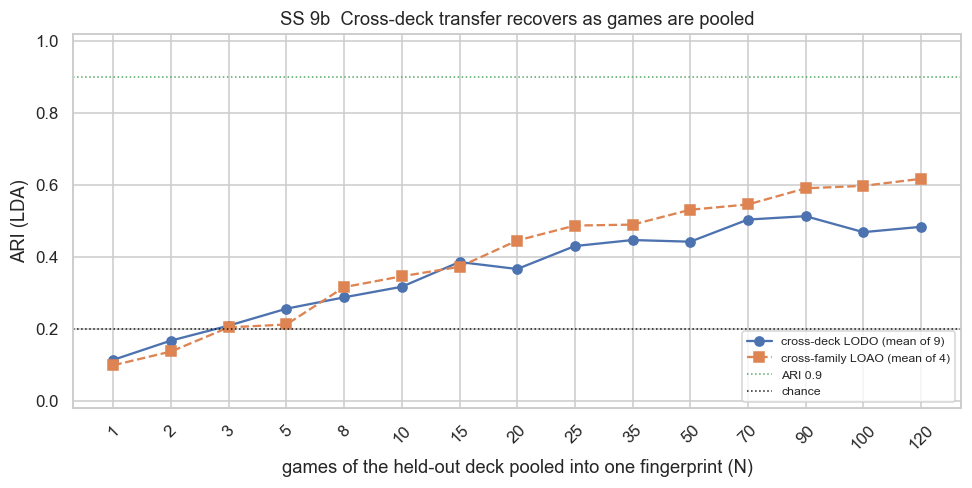

       within-deck:  N for ARI 0.5 = 5   N for ARI 0.9 = 35   best 0.992 at N = 120
   cross-deck LODO:  N for ARI 0.5 = 70   N for ARI 0.9 = None   best 0.513 at N = 90
 cross-family LOAO:  N for ARI 0.5 = 50   N for ARI 0.9 = None   best 0.617 at N = 120


In [16]:
# ===== SS 9b - the two transfer curves on their own, without the within-deck ceiling =====
# Both curves were computed in SS 8-9 (`cross_agg_curve`); nothing is recomputed here.
fig, ax = plt.subplots(figsize=(9, 4.6)); xs = range(len(curve_lodo.index))
ax.plot(xs, curve_lodo.values, "o-", label="cross-deck LODO (mean of 9)")
ax.plot(xs, curve_loao.values, "s--", label="cross-family LOAO (mean of 4)")
ax.axhline(0.9, color="g", ls=":", lw=1, label="ARI 0.9"); ax.axhline(CHANCE, color="k", ls=":", lw=1, label="chance")
ax.set_xticks(list(xs)); ax.set_xticklabels(curve_lodo.index, rotation=45)
ax.set_xlabel("games of the held-out deck pooled into one fingerprint (N)")
ax.set_ylabel("ARI (LDA)"); ax.set_ylim(-0.02, 1.02)
ax.set_title("SS 9b  Cross-deck transfer recovers as games are pooled")
ax.legend(fontsize=8); fig.tight_layout(); plt.show()

for name, c in [("within-deck", curve_within), ("cross-deck LODO", curve_lodo), ("cross-family LOAO", curve_loao)]:
    n50 = next((N for N in c.index if c[N] >= 0.5), None)
    n90 = next((N for N in c.index if c[N] >= 0.9), None)
    print(f"{name:>18}:  N for ARI 0.5 = {n50}   N for ARI 0.9 = {n90}   "
          f"best {c.max():.3f} at N = {c.idxmax()}")

## 10 - Domain-shift correction

Re-express every statistic as a **deviation from the average player of the same deck** (per-deck z-score) and re-run both cross-deck tests. This strips the deck's overall bias while keeping the within-deck differences between styles. How far the bars move is a direct measure of how much of the LODO / LOAO gap was deck bias rather than a genuine failure of the statistics.

> Note this is a **transductive** correction - it needs a sample of the held-out deck's games to compute that deck's mean. It is a diagnostic, not a deployable model.

Cross-deck ARI before / after re-expressing each statistic as a deviation from the same-deck average player:


,raw statistics,deck z-scored
LDA LODO,0.127,0.156
LDA LOAO,0.118,0.147
KMeans LODO,0.050,0.071
KMeans LOAO,0.039,0.069


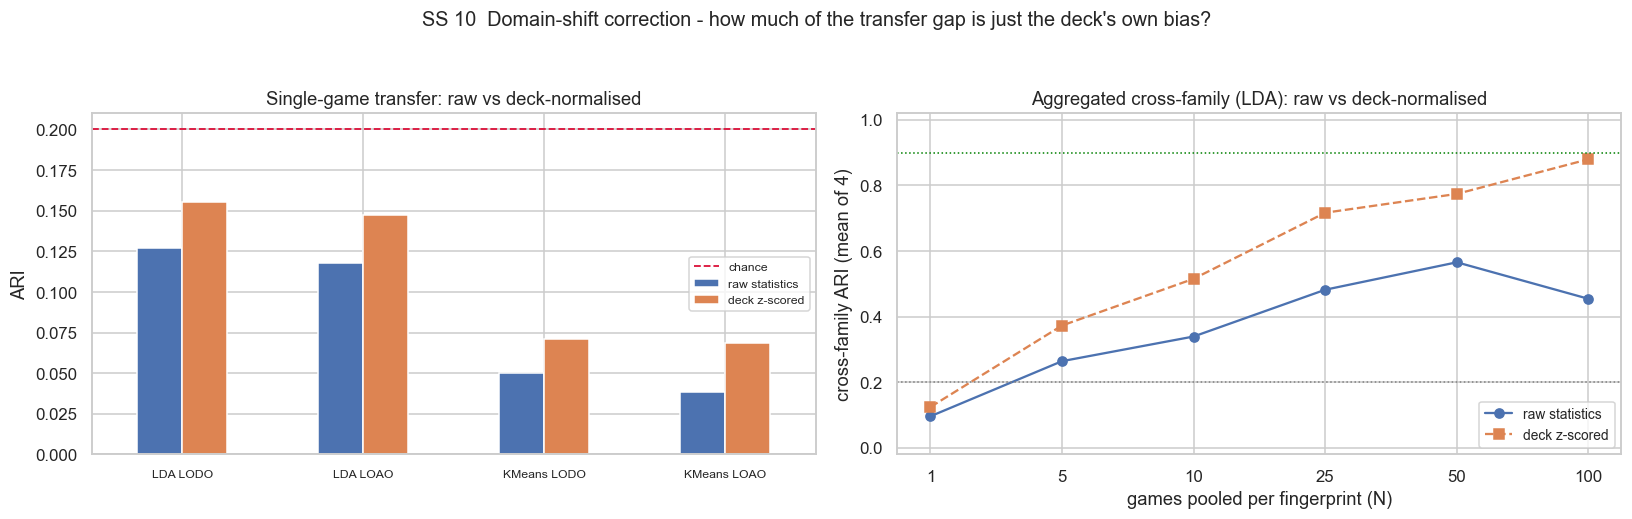

In [17]:
# ===== SS 10 - domain-shift correction: deviation from the SAME-DECK average player =====
def deck_zscore(frame, feats):
    g = frame.copy()
    g[feats] = g[feats].fillna(g.groupby("deck")[feats].transform("median")).fillna(0.0)
    g[feats] = g.groupby("deck")[feats].transform(lambda s: (s - s.mean()) / (s.std(ddof=0) + 1e-9))
    return g

df_dz = deck_zscore(df, FEATURES)
bars = {}
for label, frame in [("raw statistics", df), ("deck z-scored", df_dz)]:
    l1 = transfer(frame, FEATURES, "deck"); l2 = transfer(frame, FEATURES, "deck_family")
    bars[label] = {
        "LDA LODO": l1["LDA ARI"].mean(), "LDA LOAO": l2["LDA ARI"].mean(),
        "KMeans LODO": l1["KMeans ARI (fit on train)"].mean(),
        "KMeans LOAO": l2["KMeans ARI (fit on train)"].mean(),
    }
barsdf = pd.DataFrame(bars)
print("Cross-deck ARI before / after re-expressing each statistic as a deviation from the "
      "same-deck average player:")
display(barsdf.round(3))

fig, ax = plt.subplots(1, 2, figsize=(15, 4.8))
barsdf.plot.bar(ax=ax[0]); ax[0].axhline(CHANCE, color="crimson", ls="--", lw=1.2, label="chance")
ax[0].set_title("Single-game transfer: raw vs deck-normalised"); ax[0].set_ylabel("ARI")
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=0, fontsize=8); ax[0].legend(fontsize=8)
c_raw = cross_agg_curve(df,    FEATURES, "deck_family", reps=200)
c_dz  = cross_agg_curve(df_dz, FEATURES, "deck_family", reps=200)
xs = range(len(c_raw.index))
ax[1].plot(xs, c_raw.values, "o-", label="raw statistics")
ax[1].plot(xs, c_dz.values, "s--", label="deck z-scored")
ax[1].axhline(0.9, color="green", ls=":", lw=1); ax[1].axhline(CHANCE, color="gray", ls=":", lw=1)
ax[1].set_xticks(list(xs)); ax[1].set_xticklabels(c_raw.index); ax[1].set_ylim(-0.02, 1.02)
ax[1].set_xlabel("games pooled per fingerprint (N)"); ax[1].set_ylabel("cross-family ARI (mean of 4)")
ax[1].set_title("Aggregated cross-family (LDA): raw vs deck-normalised"); ax[1].legend(fontsize=9)
fig.suptitle("SS 10  Domain-shift correction - how much of the transfer gap is just the deck's own bias?",
             fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.94]); plt.show()

## 11 - Summary

Every headline number from the notebook on one ARI scale (chance line 0.20, perfect = 1.000).

,protocol,model,ARI
0,"pooled, per game",KMeans (k=5),0.038
1,"pooled, per game",LDA (5-fold),0.118
2,"pooled, N=120 fingerprint",KMeans (k=5),0.956
3,"pooled, N=120 fingerprint",LDA (held-out),1.000
4,within-deck (mean of 9),KMeans (k=5),0.082
5,within-deck (mean of 9),LDA (5-fold),0.221
6,cross-deck LODO (mean of 9),KMeans (fit on train),0.050
7,cross-deck LODO (mean of 9),LDA,0.127
8,cross-family LOAO (mean of 4),KMeans (fit on train),0.039
9,cross-family LOAO (mean of 4),LDA,0.118


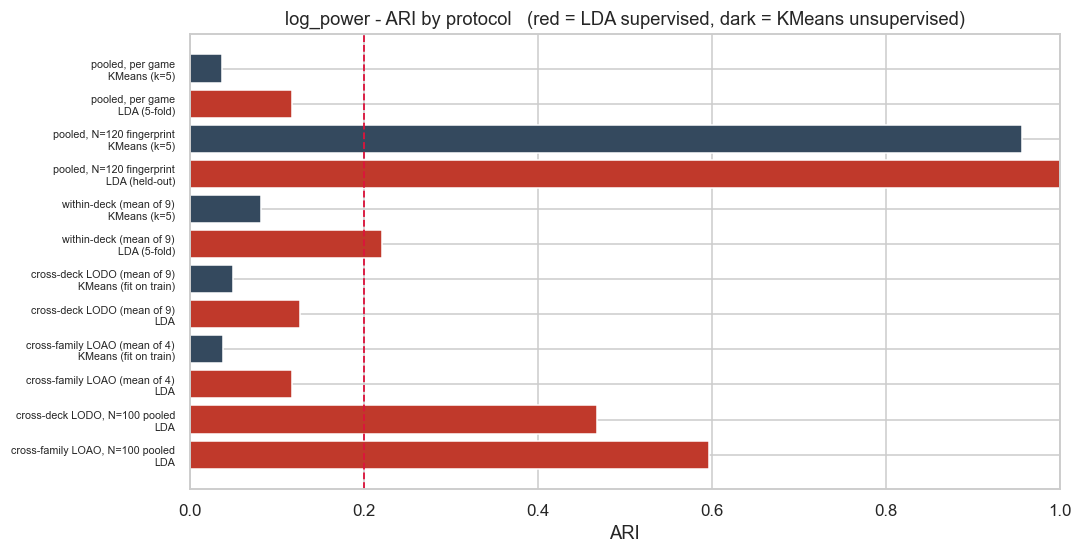

In [18]:
# ===== SS 11 - everything on one scale =====
final = pd.DataFrame({
    "protocol": [
        "pooled, per game", "pooled, per game",
        "pooled, N=120 fingerprint", "pooled, N=120 fingerprint",
        "within-deck (mean of 9)", "within-deck (mean of 9)",
        "cross-deck LODO (mean of 9)", "cross-deck LODO (mean of 9)",
        "cross-family LOAO (mean of 4)", "cross-family LOAO (mean of 4)",
        "cross-deck LODO, N=100 pooled", "cross-family LOAO, N=100 pooled",
    ],
    "model": ["KMeans (k=5)", "LDA (5-fold)",
              "KMeans (k=5)", "LDA (held-out)",
              "KMeans (k=5)", "LDA (5-fold)",
              "KMeans (fit on train)", "LDA",
              "KMeans (fit on train)", "LDA",
              "LDA", "LDA"],
    "ARI": [ari_km, ari_lda,
            sweep.loc[120, "KMeans ARI"], sweep.loc[120, "LDA ARI"],
            within_df["KMeans ARI (k=5)"].mean(), within_df["LDA ARI (5-fold)"].mean(),
            lodo["KMeans ARI (fit on train)"].mean(), lodo["LDA ARI"].mean(),
            loao["KMeans ARI (fit on train)"].mean(), loao["LDA ARI"].mean(),
            curve_lodo.loc[100], curve_loao.loc[100]],
})
display(final.style.format({"ARI": "{:.3f}"}).background_gradient(cmap="rocket_r", subset=["ARI"])
        .set_caption("log_power - every headline number, all ARI, chance line 0.20, perfect = 1.000"))

fig, ax = plt.subplots(figsize=(10, 5.2))
lab = final["protocol"] + "\n" + final["model"]
colors = ["#34495e" if "KMeans" in m else "#c0392b" for m in final["model"]]
ax.barh(range(len(final))[::-1], final["ARI"], color=colors)
ax.set_yticks(range(len(final))[::-1]); ax.set_yticklabels(lab, fontsize=7)
ax.axvline(CHANCE, color="crimson", ls="--", lw=1.2); ax.set_xlabel("ARI"); ax.set_xlim(0, 1)
ax.set_title("log_power - ARI by protocol   (red = LDA supervised, dark = KMeans unsupervised)")
fig.tight_layout(); plt.show()

## 12 - Reading the results

*(Written from the run above - 40,497 games, 35 statistics. Every number is an ARI against the 0.20 chance line.)*

**1. One game tells you very little (SS 5, 5b).** Unsupervised KMeans on single games, pooled over 9 decks and random opponents, lands at **ARI 0.038** - effectively the floor, far under the 0.20 line. The supervised LDA gets **0.118**: still below the line, but its 41.1% accuracy is double the 20% baseline, so the signal is genuinely there and merely buried under per-game variance. The gap between the two is what labels buy you at the single-game level.

**2. Aggregation is what separates the styles (SS 6).** Pooling games into fingerprints moves both models a long way: the held-out LDA passes ARI 0.80 at **N = 25** games and 0.90 at **N = 50**; unsupervised KMeans needs **N = 70** and **N = 90** for the same marks. A play-style is a distribution over games, and with decks pooled ~50 games is enough to recover it almost perfectly.

**3. Within-deck is modest, and cross-deck costs most of it (SS 7 vs SS 8-9).**

| | LDA | KMeans (fit on train) | KMeans (fit on held-out) |
|---|---|---|---|
| within-deck (mean of 9) | **0.221** | - | 0.082 |
| cross-deck LODO (mean of 9) | **0.127** | 0.050 | 0.088 |
| cross-family LOAO (mean of 4) | **0.118** | 0.039 | 0.050 |

Holding the deck constant, the per-game LDA reaches 0.221 - **the only single-game protocol in the notebook that clears the 0.20 line**, and only just (best `MurlocDruid` 0.285, worst `AggroPirateWarrior` 0.158). Moving to an unseen deck costs **43% of that** (0.221 -> 0.127) and drops back under the line. **LOAO is barely worse than LODO** (0.118 vs 0.127) - but read that against the deck-composition note in SS 8-9: the 9 decks are 9 different classes sharing ~2% of their cards, so LODO already removes essentially the whole card pool of the held-out deck and LOAO has little left to take away. The near-equality is a property of this deck matrix, not evidence that the leak is per-deck rather than per-family.

**4. The unsupervised transfer result is the sharpest evidence of deck entanglement.** KMeans centroids learned on the training decks score **0.050** on a held-out deck - *worse* than simply re-clustering that deck's own games from scratch (**0.088**). Carrying the clusters across a deck boundary actively hurts, which means the centroids sit on coordinates that describe the deck rather than the player.

**5. Pooling fixes noise, not domain shift (SS 8-9, 9b).** With decks pooled, N = 50 games was enough for ARI 0.90. The three-protocol sweep says the same thing more sharply: **within-deck** fingerprints climb past 0.90 by **N = 35** and reach 0.99 at N = 120, while across decks the identical aggregation plateaus at **0.469** (LODO) and **0.597** (LOAO) even at N = 100 games. The gap between those curves does not close with more data - more games on the new deck do not buy you a model that was trained on the wrong coordinates.

**6. Deck-normalisation recovers a real but partial share (SS 10).** Re-expressing each statistic as a deviation from the same-deck average player lifts LDA LODO **0.127 -> 0.156** and LOAO **0.118 -> 0.147**, and KMeans LODO **0.050 -> 0.071**, LOAO **0.039 -> 0.069** - a real gain, but none of it reaches the 0.20 line. So part of the gap is a pure per-deck offset that a z-score removes, and most of it is not. SS 3b shows why: the top-F statistics do not merely shift between decks, their style ordering **crosses**.

### What this means for the dataset

Simple `Power.log` statistics carry real play-style signal, but they carry deck identity at least as strongly, and **at the single-game level only the within-deck LDA clears the 0.20 reference line at all** - `f_avg_card_cost`, `f_face_dmg_per_turn` and `f_deck_left_end` report what the *deck* hands the player as much as what the player chose. That reproduces the deck-entanglement conclusion of the `log_v2` study on the realistic, client-shaped log format, and it does so under a harder constraint: because a real log records only the action taken and never the legal options it was chosen from, the choice-relative (`ch_*`) block that partially fixed this in `log_v2` cannot be built here at all.

**Compare against [`log_v2_analysis/three_blocks/`](../log_v2_analysis/three_blocks/)**, which runs the same KMeans / LDA / ARI policy on the instrumented JSONL. The difference between the two is the price of the realistic format: no legal-option sets, and only what one client could see.